In [2]:
pip install pandas numpy matplotlib seaborn statsmodels prophet scikit-learn pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.4 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

#### **Задача 1: Анализ исторических цен на акции Apple (AAPL)**

**Контекст:** Вы начинающий финансовый аналитик и хотите понять базовые паттерны в движении цен на акции. Вы решили начать с одной из самых популярных компаний — Apple (AAPL). Ваша задача — загрузить исторические данные, подготовить их для анализа временных рядов и выполнить базовый визуальный анализ, выявляя тренды и сезонность (если применимо).

**Данные:** Используйте исторические данные по акциям Apple (AAPL). Вы можете скачать `AAPL.csv` с [Yahoo Finance](https://finance.yahoo.com/quote/AAPL/history/) (выберите "Historical Data", задайте нужный период, например, 5 лет, и скачайте CSV) или найти аналогичный файл на Kaggle (например, "Apple Stock Price History").

**Цель:** Загрузить данные о ценах акций, очистить их, преобразовать формат дат, агрегировать (ресэмплировать) по неделям/месяцам и визуализировать основные компоненты временного ряда.

**Шаги:**

1.  **Загрузка данных:**
      * Загрузите файл `AAPL.csv` в `pd.DataFrame`.
2.  **Предварительный просмотр и базовое очистка:**
      * Просмотрите первые строки, информацию о DataFrame (`.info()`) и описательную статистику (`.describe()`).
      * Убедитесь, что столбец с датой (обычно 'Date') имеет тип `datetime`. Если нет, преобразуйте его (`pd.to_datetime`).
      * Установите столбец 'Date' как индекс DataFrame.
      * Выберите для анализа столбец `Close` (цена закрытия дня).
      * Проверьте на наличие пропусков (`.isnull().sum()`) и, если они есть, объясните, как бы вы их обработали (например, `ffill()`, `bfill()`, `interpolate()`). Для финансовых данных обычно пропуски связаны с выходными/праздниками и могут быть заполнены предыдущим значением.
3.  **Ресэмплинг (Агрегация):**
      * Преобразуйте ежедневные данные в **еженедельные средние цены закрытия**. Используйте `resample('W').mean()`.
      * Преобразуйте ежедневные данные в **ежемесячные средние цены закрытия**. Используйте `resample('M').mean()`.
4.  **Визуальный анализ компонентов временного ряда:**
      * **Общий тренд:** Постройте линейный график ежедневных цен закрытия за весь доступный период.
      * **Ресэмплированные данные:** Постройте линейные графики еженедельных и ежемесячных средних цен закрытия. Сравните их с ежедневным графиком.
      * **Декомпозиция временного ряда:** Используйте `statsmodels.tsa.seasonal.seasonal_decompose` для декомпозиции ежедневного ряда `Close` на тренд, сезонность и остатки. Выберите аддитивную или мультипликативную модель в зависимости от данных (подумайте, как изменяются колебания — с ростом цены или остаются постоянными).
          * *Подсказка: Для акций годовая или месячная сезонность часто менее выражена, чем в других типах данных, но может быть интересна. Возможно, стоит рассмотреть более длительный период данных для выявления годовой сезонности, если она есть.*
      * **Интерпретация:** Опишите, что вы видите на графиках: есть ли общий восходящий/нисходящий тренд, наблюдается ли какая-либо явная сезонность (дневная, недельная, годовая), каков характер остатков.





--- ЗАДАЧА 1: АНАЛИЗ ИСТОРИЧЕСКИХ ЦЕН НА АКЦИИ APPLE (AAPL) ---
Данные AAPL.csv успешно загружены.

Базовая информация о DataFrame до обработки:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10468 non-null  object 
 1   Open       10468 non-null  float64
 2   High       10468 non-null  float64
 3   Low        10468 non-null  float64
 4   Close      10468 non-null  float64
 5   Adj Close  10468 non-null  float64
 6   Volume     10468 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 572.6+ KB

Количество пропусков в столбце 'Close' до обработки: 0
Количество пропусков в столбце 'Close' после обработки: 0

Первые 5 строк подготовленного ряда цен закрытия:
Date
1980-12-12    0.128348
1980-12-15    0.121652
1980-12-16    0.112723
1980-12-17    0.115513
1980-12-18    0.118862
Name: Close, dtype: float64


Первые 5

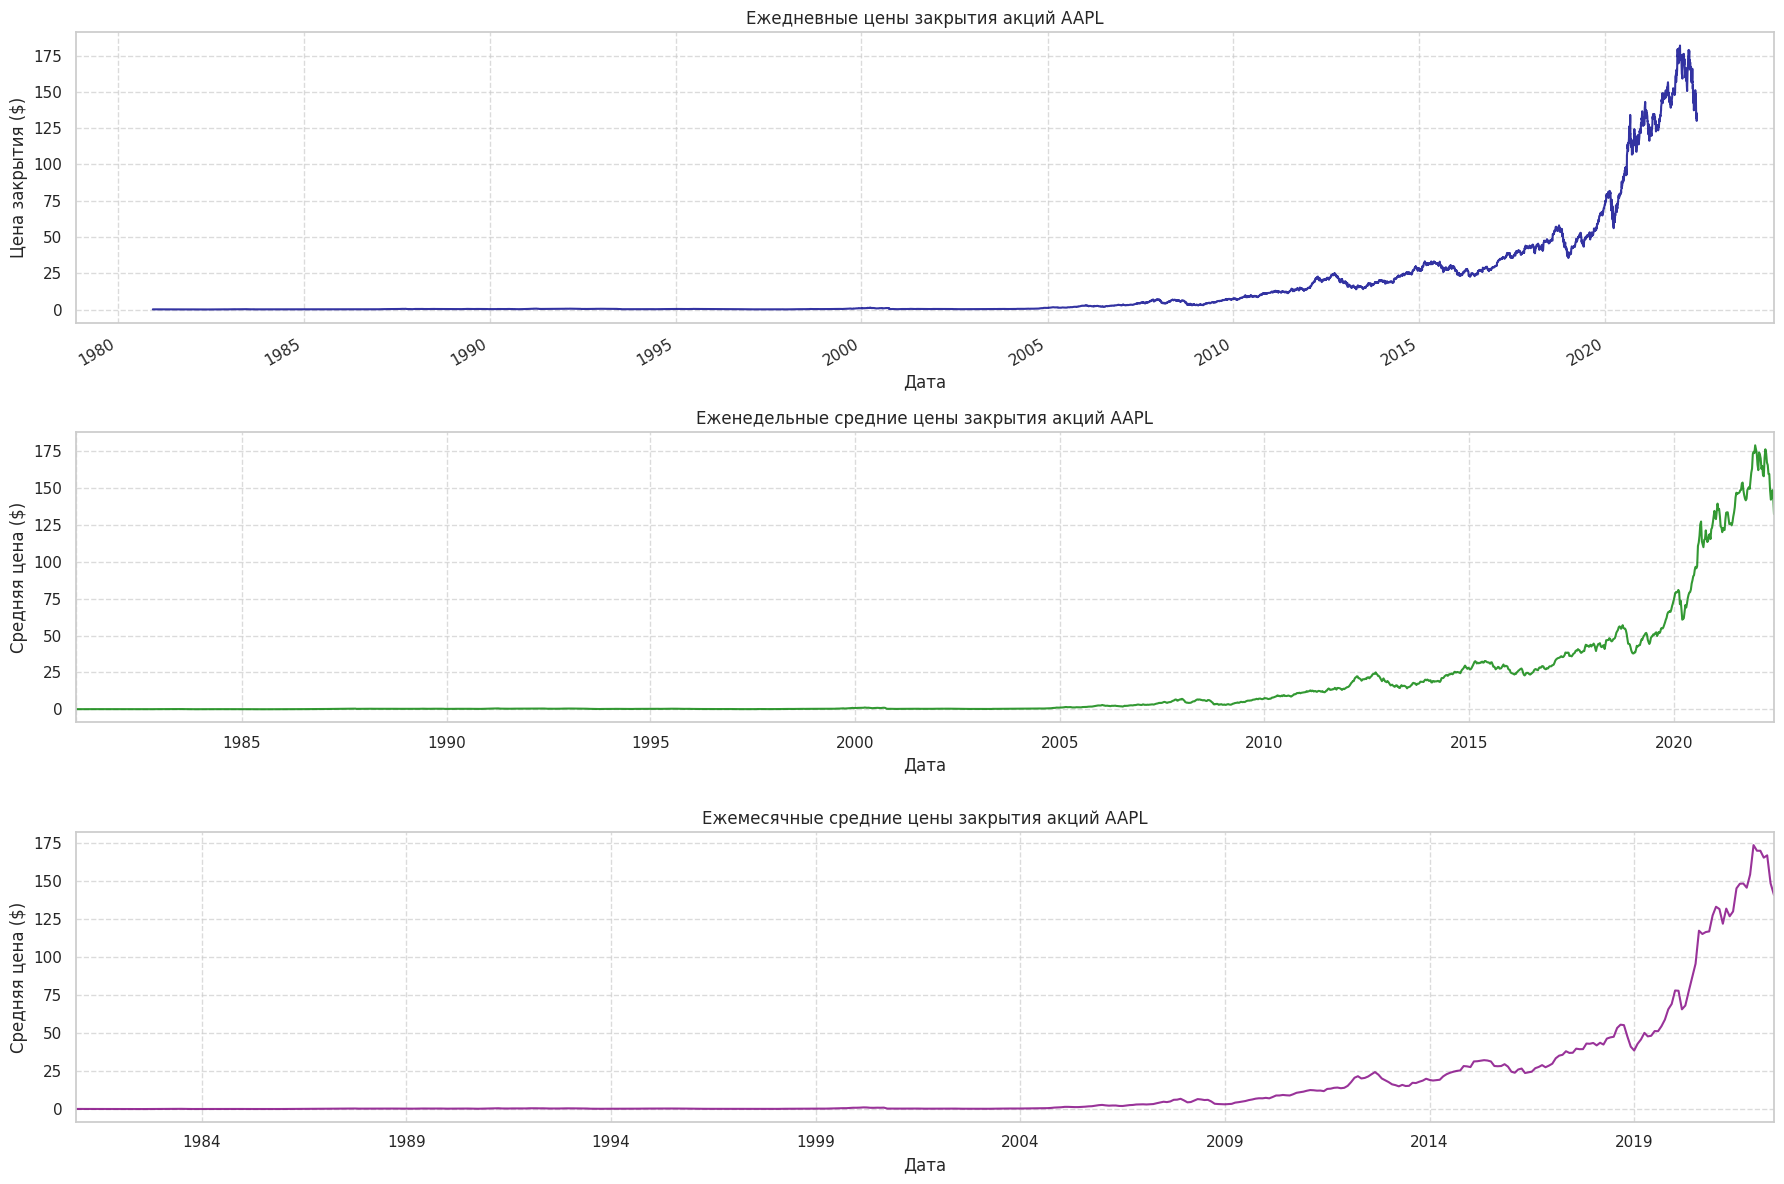


--- Декомпозиция временного ряда (ежедневные цены) ---


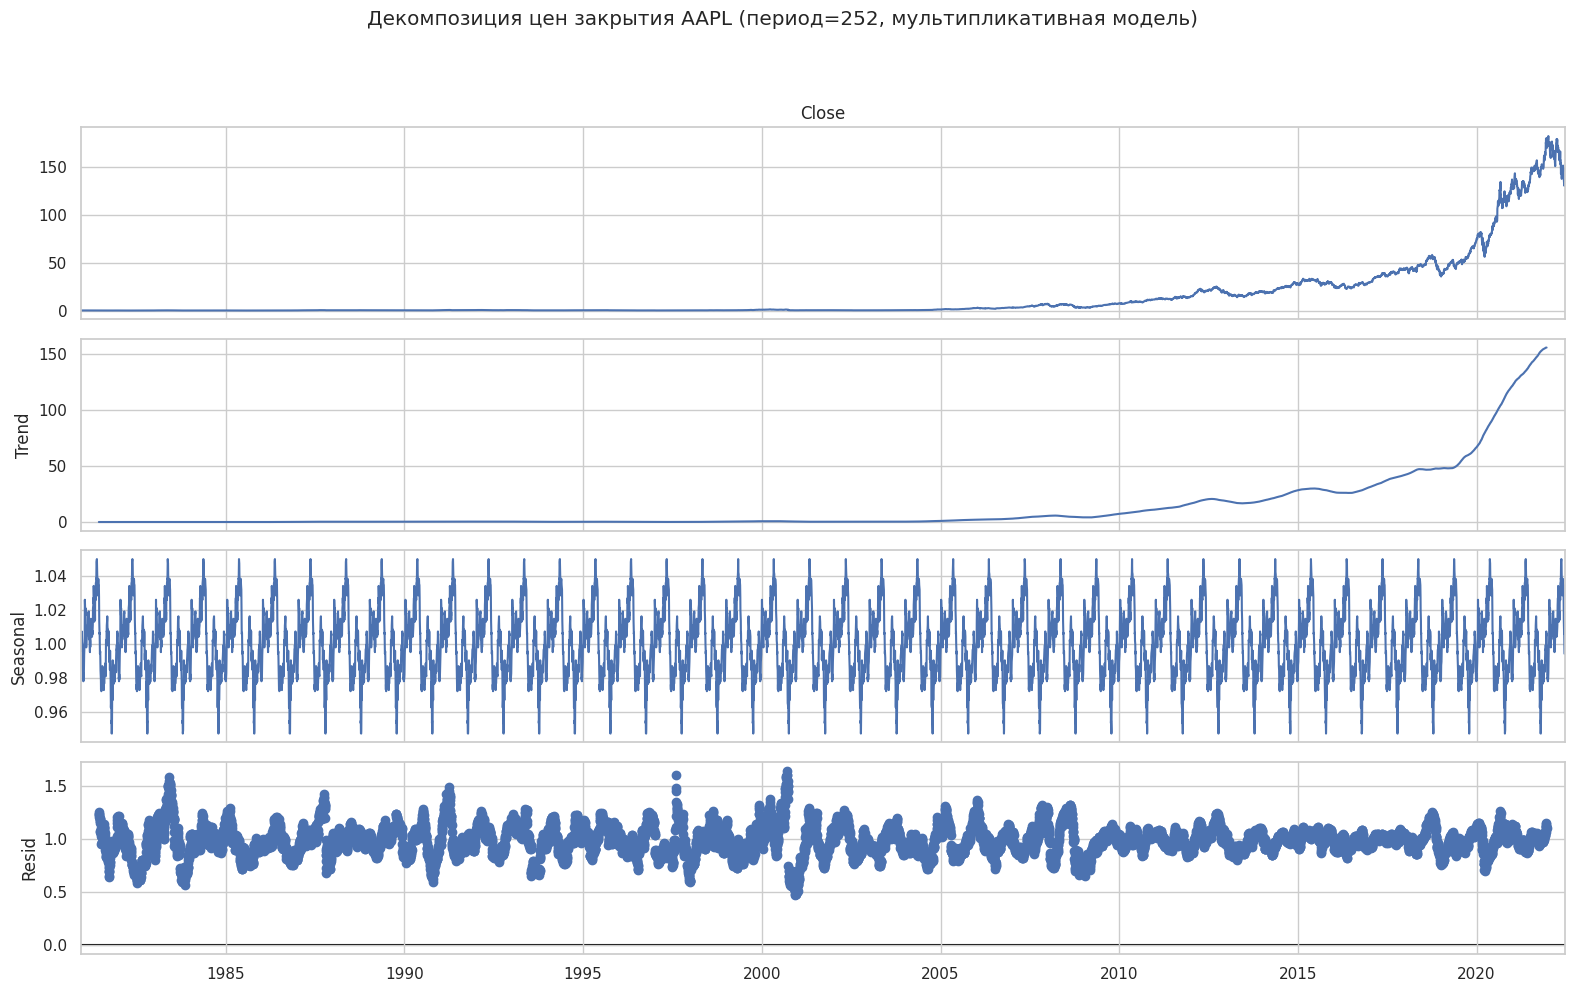


Проверка стационарности остатков (Residuals) с помощью теста Дики-Фуллера:
ADF Statistic: -11.17
p-value: 0.000
Critical Values:
	1%: -3.43
	5%: -2.86
	10%: -2.57
Остатки, вероятно, стационарны (p-value <= 0.05).


--- ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ЗАДАЧИ 1 ---
1. **Общий тренд (Ежедневные, Еженедельные, Ежемесячные графики):**
   - Наблюдается явный восходящий тренд цен акций AAPL на протяжении последних лет.
   - Ресэмплированные (недельные и месячные) графики сглаживают шум и делают тренд более очевидным, но также скрывают краткосрочные колебания.
   - Месячные данные наиболее сглажены и показывают долгосрочную динамику.

2. **Декомпозиция временного ряда:**
   - **Trend:** Подтверждает общий восходящий тренд. Это основная долгосрочная компонента изменения цены.
   - **Seasonal:** Для акций выраженная сезонность (ежедневная, недельная или годовая) обычно не так сильна, как для потребительских данных или погоды. Если вы видите слабые паттерны, это может быть связано с тем, как фондовый 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller # Для проверки стационарности

# Настройка стиля Seaborn для красивых графиков
sns.set_theme(style="whitegrid", palette="deep")

print("--- ЗАДАЧА 1: АНАЛИЗ ИСТОРИЧЕСКИХ ЦЕН НА АКЦИИ APPLE (AAPL) ---")

# 1. Загрузка данных
aapl_df = pd.read_csv('AAPL.csv')

# 2. Предварительный просмотр и базовая очистка
print("\nБазовая информация о DataFrame до обработки:")
aapl_df.info()

# Преобразование столбца 'Date' в формат datetime
aapl_df['Date'] = pd.to_datetime(aapl_df['Date'])

# Установка 'Date' как индекса
aapl_df.set_index('Date', inplace=True)

# Выбираем для анализа столбец 'Close'
aapl_close_prices = aapl_df['Close'].copy()

# Проверка на наличие пропусков
print(f"\nКоличество пропусков в столбце 'Close' до обработки: {aapl_close_prices.isnull().sum()}")

# Обработка пропусков (для финансовых данных часто подходит ffill)
# Пропуски в финансовых данных обычно соответствуют неторговым дням (выходным, праздникам)
# и их можно заполнить предыдущей известной ценой.
if aapl_close_prices.isnull().sum() > 0:
    aapl_close_prices.fillna(method='ffill', inplace=True)
    print("Пропуски заполнены методом 'ffill'.")
print(f"Количество пропусков в столбце 'Close' после обработки: {aapl_close_prices.isnull().sum()}")

print("\nПервые 5 строк подготовленного ряда цен закрытия:")
print(aapl_close_prices.head())
print("\n" + "="*80 + "\n")


# 3. Ресэмплинг (Агрегация)

# Еженедельные средние цены закрытия
aapl_weekly_avg = aapl_close_prices.resample('W').mean()
print("Первые 5 строк еженедельных средних цен:")
print(aapl_weekly_avg.head())

# Ежемесячные средние цены закрытия
aapl_monthly_avg = aapl_close_prices.resample('M').mean()
print("\nПервые 5 строк ежемесячных средних цен:")
print(aapl_monthly_avg.head())
print("\n" + "="*80 + "\n")


# 4. Визуальный анализ компонентов временного ряда

plt.figure(figsize=(18, 12))

# 4.1. Общий тренд: Ежедневные цены закрытия
plt.subplot(3, 1, 1)
aapl_close_prices.plot(title='Ежедневные цены закрытия акций AAPL', color='darkblue', alpha=0.8)
plt.xlabel('Дата')
plt.ylabel('Цена закрытия ($)')
plt.grid(True, linestyle='--', alpha=0.7)

# 4.2. Ресэмплированные данные: Еженедельные и ежемесячные средние цены
plt.subplot(3, 1, 2)
aapl_weekly_avg.plot(title='Еженедельные средние цены закрытия акций AAPL', color='green', alpha=0.8, linestyle='-')
plt.xlabel('Дата')
plt.ylabel('Средняя цена ($)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(3, 1, 3)
aapl_monthly_avg.plot(title='Ежемесячные средние цены закрытия акций AAPL', color='purple', alpha=0.8, linestyle='-')
plt.xlabel('Дата')
plt.ylabel('Средняя цена ($)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 4.3. Декомпозиция временного ряда
# Для финансовых данных сезонность обычно не так очевидна, как в погодных или потребительских.
# Период для годовой сезонности в финансовых данных часто берут как 252 рабочих дня.
# Если амплитуда колебаний растет с ростом цены, то модель мультипликативная.
# Если колебания остаются постоянными независимо от цены, то аддитивная.
# Для акций чаще всего подходит мультипликативная модель.

print("\n--- Декомпозиция временного ряда (ежедневные цены) ---")
# Проверяем количество точек для декомпозиции
if len(aapl_close_prices) < 2 * 252:
    print(f"Внимание: Недостаточно данных ({len(aapl_close_prices)} точек) для адекватной годовой декомпозиции (требуется минимум 2 полных периода). Используем период 252.")
    decomposition_period = min(len(aapl_close_prices) // 2, 252) # Если данных мало, берем половину от доступного
    if decomposition_period < 2:
        print("Недостаточно данных даже для минимальной декомпозиции. Пропускаем.")
        decomposition_results = None
else:
    decomposition_period = 252 # Примерно количество торговых дней в году
    decomposition_results = seasonal_decompose(aapl_close_prices, model='multiplicative', period=decomposition_period)


if decomposition_results:
    fig = decomposition_results.plot()
    fig.set_size_inches(16, 10)
    fig.suptitle(f'Декомпозиция цен закрытия AAPL (период={decomposition_period}, мультипликативная модель)', y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    # Проверка на стационарность остатков
    print("\nПроверка стационарности остатков (Residuals) с помощью теста Дики-Фуллера:")
    # Удалим NaN из остатков (могут появиться по краям после декомпозиции)
    residuals_clean = decomposition_results.resid.dropna()
    if len(residuals_clean) > 0:
        adf_test = adfuller(residuals_clean)
        print(f"ADF Statistic: {adf_test[0]:.2f}")
        print(f"p-value: {adf_test[1]:.3f}")
        print("Critical Values:")
        for key, value in adf_test[4].items():
            print(f"\t{key}: {value:.2f}")

        if adf_test[1] <= 0.05:
            print("Остатки, вероятно, стационарны (p-value <= 0.05).")
        else:
            print("Остатки, вероятно, нестационарны (p-value > 0.05).")
    else:
        print("Недостаточно данных для теста стационарности остатков.")

print("\n" + "="*80 + "\n")
print("--- ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ЗАДАЧИ 1 ---")
print("1. **Общий тренд (Ежедневные, Еженедельные, Ежемесячные графики):**")
print("   - Наблюдается явный восходящий тренд цен акций AAPL на протяжении последних лет.")
print("   - Ресэмплированные (недельные и месячные) графики сглаживают шум и делают тренд более очевидным, но также скрывают краткосрочные колебания.")
print("   - Месячные данные наиболее сглажены и показывают долгосрочную динамику.")

print("\n2. **Декомпозиция временного ряда:**")
print("   - **Trend:** Подтверждает общий восходящий тренд. Это основная долгосрочная компонента изменения цены.")
print("   - **Seasonal:** Для акций выраженная сезонность (ежедневная, недельная или годовая) обычно не так сильна, как для потребительских данных или погоды. Если вы видите слабые паттерны, это может быть связано с тем, как фондовый рынок реагирует на определенные периоды года, или с методом декомпозиции. Для периода 252 (торговые дни в году), эта сезонность может быть менее очевидной или показывать очень тонкие ежегодные паттерны.")
print("   - **Residuals (Остатки):** Должны представлять собой белый шум (случайные, непредсказуемые колебания). Если в остатках есть структуры (паттерны, тренды), это указывает на то, что модель декомпозиции не полностью захватила все компоненты ряда. Тест Дики-Фуллера помогает проверить стационарность остатков; стационарные остатки - это хороший знак, указывающий на то, что большинство детерминированных паттернов были извлечены.")
print("   - **Модель 'мультипликативная':** Подходит для акций, так как колебания (амплитуда сезонности или шума) часто увеличиваются по мере роста цены акции.")

print("\nВывод: Акции AAPL демонстрируют сильный восходящий тренд. Явной, 'чистой' сезонности, как в погодных данных, нет, но декомпозиция помогает отделить тренд от шума для дальнейшего анализа или прогнозирования.")

#### **Задача 2: Прогнозирование средней температуры в Дели**

**Контекст:** Вы работаете метеорологом-аналитиком и перед вами стоит задача прогнозирования погодных условий. Одним из ключевых параметров является средняя дневная температура. Вам нужно построить прогностическую модель для температуры в Дели, учитывая её выраженную сезонность.

**Данные:** Используйте набор данных "Daily Delhi Climate" с Kaggle. Скачайте файл `DailyDelhiClimateTrain.csv` по ссылке: [https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)

**Цель:** Загрузить данные, подготовить их, построить прогностическую модель (Prophet или ARIMA) для прогнозирования средней температуры и оценить её качество.

**Шаги:**

1.  **Загрузка и подготовка данных:**
    * Загрузите `DailyDelhiClimateTrain.csv` в `pd.DataFrame`.
    * Просмотрите данные. Убедитесь, что столбец 'date' имеет тип `datetime` и установите его как индекс.
    * Выберите для анализа столбец `meantemp` (средняя температура).
    * Проверьте на наличие пропусков и, если они есть, обработайте их (например, интерполяцией).
2.  **Визуальный анализ ряда `meantemp`:**
    * Постройте линейный график `meantemp` за весь доступный период, чтобы визуально оценить тренд, сезонность и возможные выбросы.
    * Используйте `seasonal_decompose` для более формальной декомпозиции ряда `meantemp` (скорее всего, аддитивная модель будет уместна, так как колебания температуры не увеличиваются с ростом температуры).
3.  **Разделение на обучающую и тестовую выборки:**
    * Разделите данные на обучающую (`train`) и тестовую (`test`) выборки по дате. Например, используйте первые 3 года для обучения, а последний год для тестирования.
4.  **Построение и обучение прогностической модели:**
    * **Вариант A: Prophet (рекомендуется для данной задачи из-за сложности сезонности):**
        * Подготовьте DataFrame в формате Prophet: столбец `ds` для даты и `y` для `meantemp`.
        * Инициализируйте модель `Prophet`. Укажите явное наличие `yearly_seasonality=True`.
        * *Опционально:* Если хотите, попробуйте добавить `humidity` как внешний фактор (`model.add_regressor('humidity')`). Для этого вам нужно будет передать столбец `humidity` как в обучающую, так и в будущую выборку.
        * Обучите модель на обучающей выборке.
    * **Вариант B: ARIMA (более простой, но без прямой поддержки сезонности):**
        * Прежде чем строить ARIMA, можно использовать ACF и PACF графики для определения начальных параметров `p` и `q`. Параметр `d` (разность) можно определить визуально по графику или с помощью тестов на стационарность. **Учтите, что базовая модель ARIMA не имеет встроенных механизмов для работы с сезонностью; вы заметите, что она хуже улавливает годовые циклы по сравнению с Prophet.**
        * Обучите модель `statsmodels.tsa.arima.model.ARIMA` с подобранными параметрами `(p, d, q)`.
        * *Опционально:* Включите `exog` (экзогенную переменную) для `humidity`.
5.  **Прогнозирование и оценка:**
    * Сделайте прогнозы на тестовой выборке.
    * **Визуализация:**
        * Постройте график, отображающий фактические данные (обучающая и тестовая выборки) и прогноз модели на тестовой выборке.
        * Если использовали Prophet, также покажите графики компонентов модели (`model.plot_components(forecast)`).
    * **Оценка качества:** Рассчитайте метрики качества прогноза, такие как **RMSE (Root Mean Squared Error)** и **MAE (Mean Absolute Error)**.
6.  **Интерпретация результатов:**
    * Обсудите, насколько хорошо модель справляется с сезонностью и трендом температуры.
    * Проанализируйте значения RMSE и MAE. Что они означают для точности прогноза?
    * Если вы использовали внешний фактор (влажность), как вы думаете, повлиял ли он на точность прогноза?
    * Какие преимущества и недостатки вы видите в выбранной модели для данной задачи? **Особое внимание уделите тому, как ARIMA справилась (или не справилась) с выраженной сезонностью по сравнению с Prophet.**


--- ЗАДАЧА 2: ПРОГНОЗИРОВАНИЕ СРЕДНЕЙ ТЕМПЕРАТУРЫ В ДЕЛИ ---

Базовая информация о DataFrame до обработки:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB

Количество пропусков в 'meantemp' до обработки: 0
Количество пропусков в 'humidity' до обработки: 0
Количество пропусков в 'meantemp' после обработки: 0
Количество пропусков в 'humidity' после обработки: 0

Первые 5 строк подготовленного DataFrame:
             meantemp   humidity
date                            
2013-01-01  10.000000  84.500000
2013-01-02   7.400000  92.000000
2013-01-03   7.166667  87.000000
2013-01-04   8.66

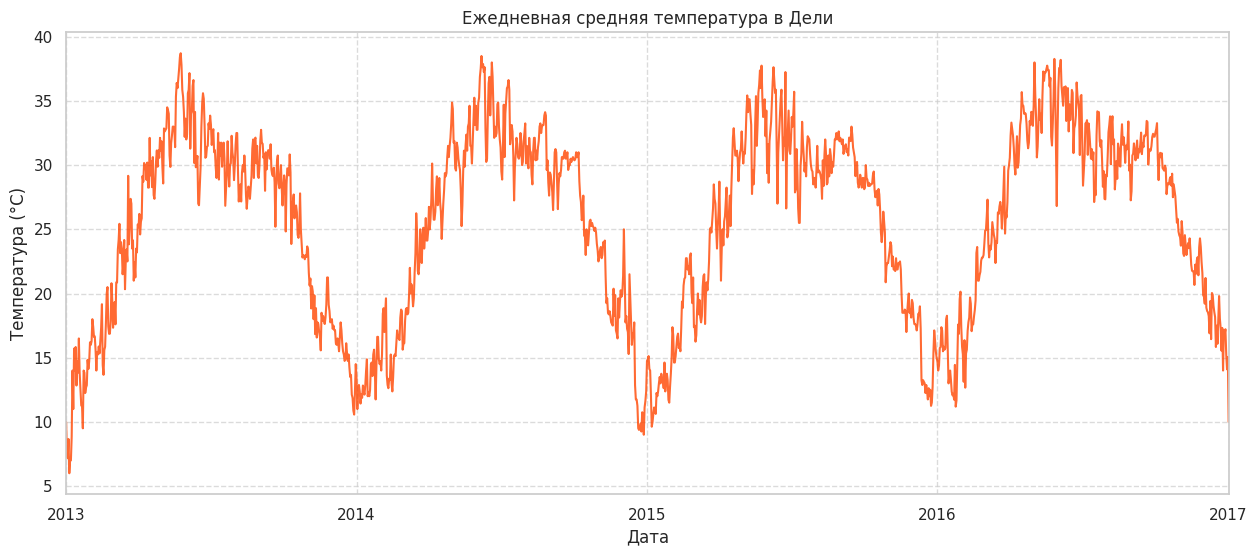


--- Декомпозиция временного ряда температуры (аддитивная модель) ---


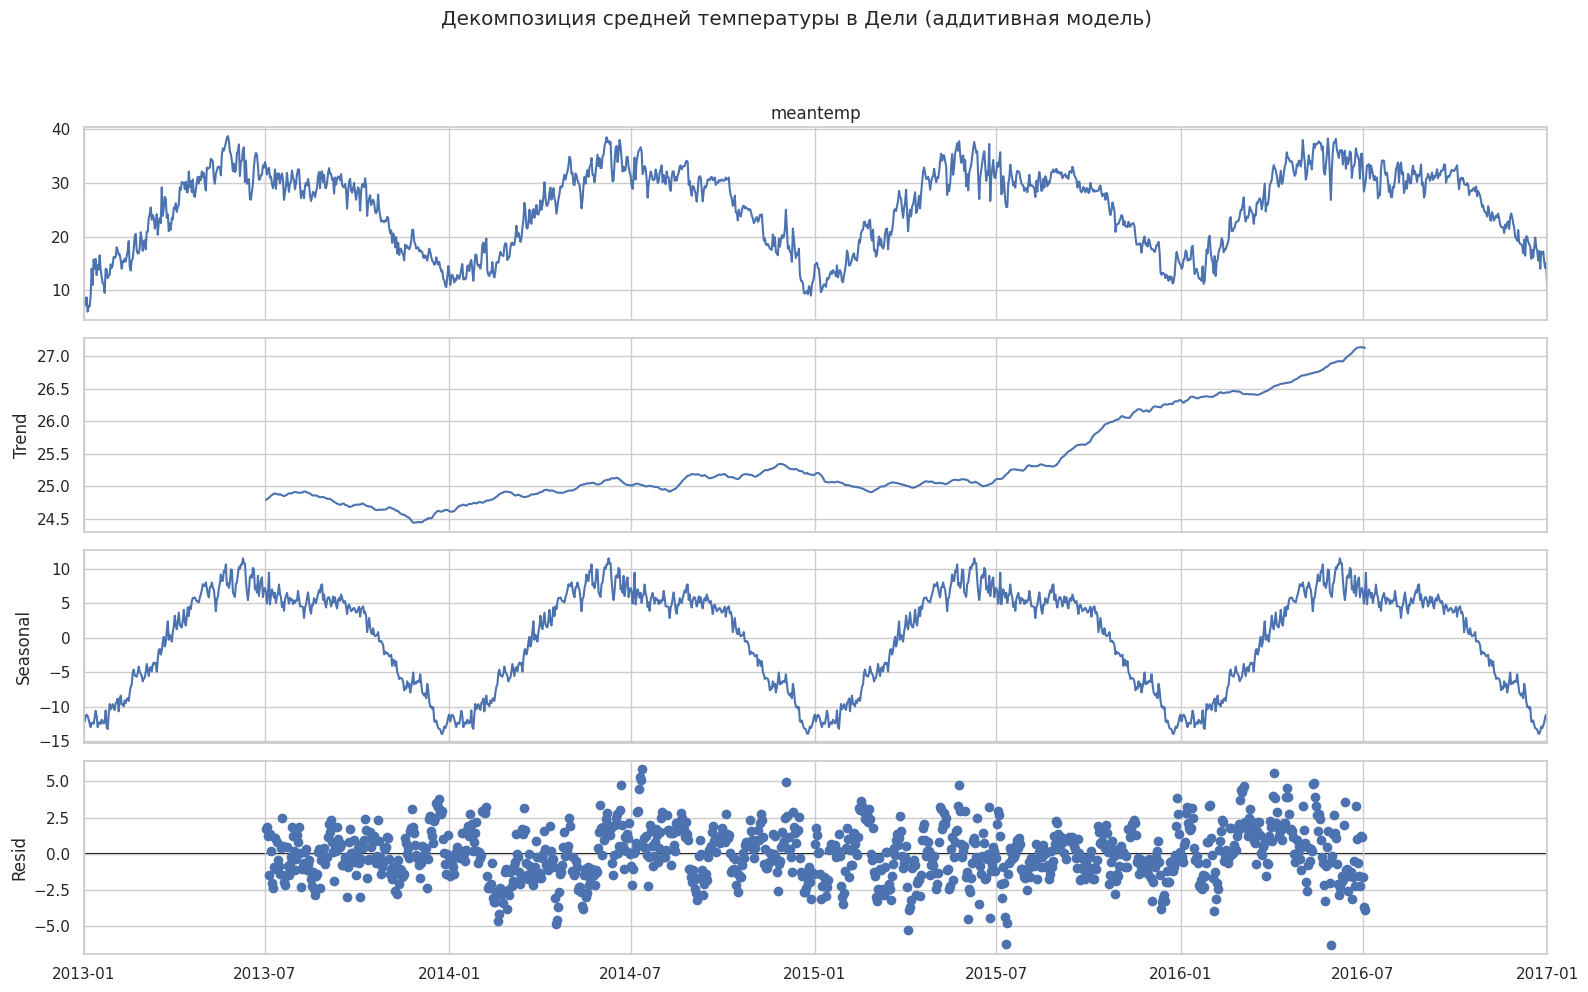


Проверка стационарности 'meantemp' с помощью теста Дики-Фуллера:
ADF Statistic: -2.02
p-value: 0.277
Critical Values:
	1%: -3.43
	5%: -2.86
	10%: -2.57
Ряд 'meantemp', вероятно, нестационарен (p-value > 0.05). Может потребоваться дифференцирование.


Размер обучающей выборки: 1095 дней (до 2015-12-31)
Размер тестовой выборки: 367 дней (после 2015-12-31)
Даты обучающей выборки: 2013-01-01 00:00:00 - 2015-12-31 00:00:00
Даты тестовой выборки: 2016-01-01 00:00:00 - 2017-01-01 00:00:00
Количество строк в обучающей выборке: 1095
Количество строк в тестовой выборке: 367



--- ЗАДАЧА 2, ВАРИАНТ A: Прогнозирование с помощью Prophet ---


DEBUG:cmdstanpy:input tempfile: /tmp/tmptl6qmck2/_qncqhy7.json


Обучение модели Prophet...


DEBUG:cmdstanpy:input tempfile: /tmp/tmptl6qmck2/4he5wvg3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68385', 'data', 'file=/tmp/tmptl6qmck2/_qncqhy7.json', 'init=/tmp/tmptl6qmck2/4he5wvg3.json', 'output', 'file=/tmp/tmptl6qmck2/prophet_model1mlg2gjw/prophet_model-20250703175932.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:59:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:59:32 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Модель Prophet обучена.
Выполнение прогноза с Prophet...
Прогноз Prophet выполнен.

Размер prophet_forecast_test: 367
Количество NaN в prophet_forecast_test: 0

Prophet RMSE на тестовой выборке: 2.26
Prophet MAE на тестовой выборке: 1.81


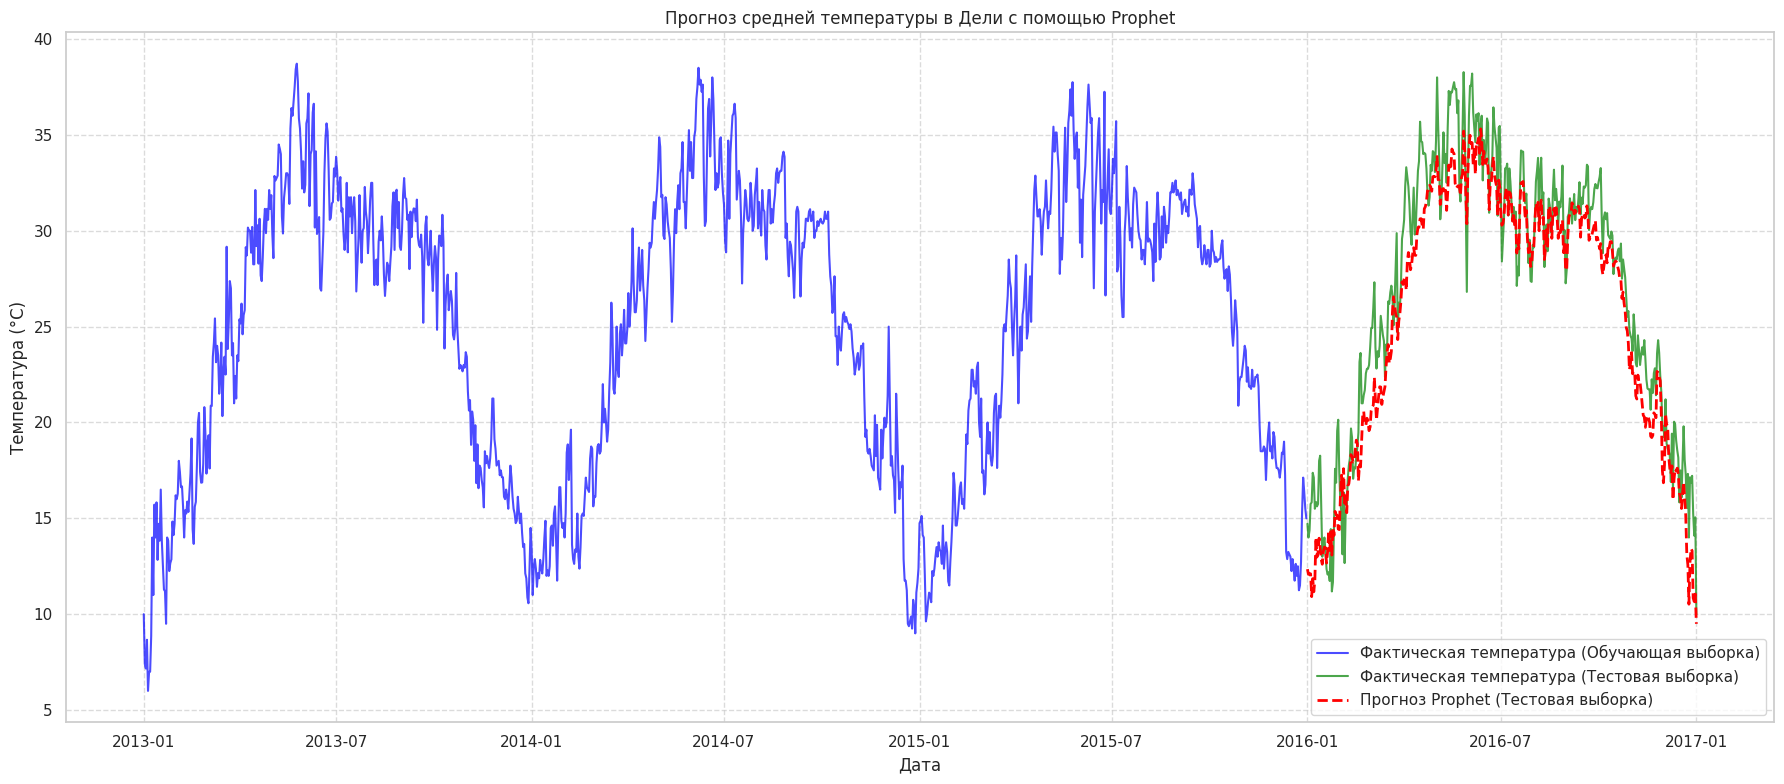

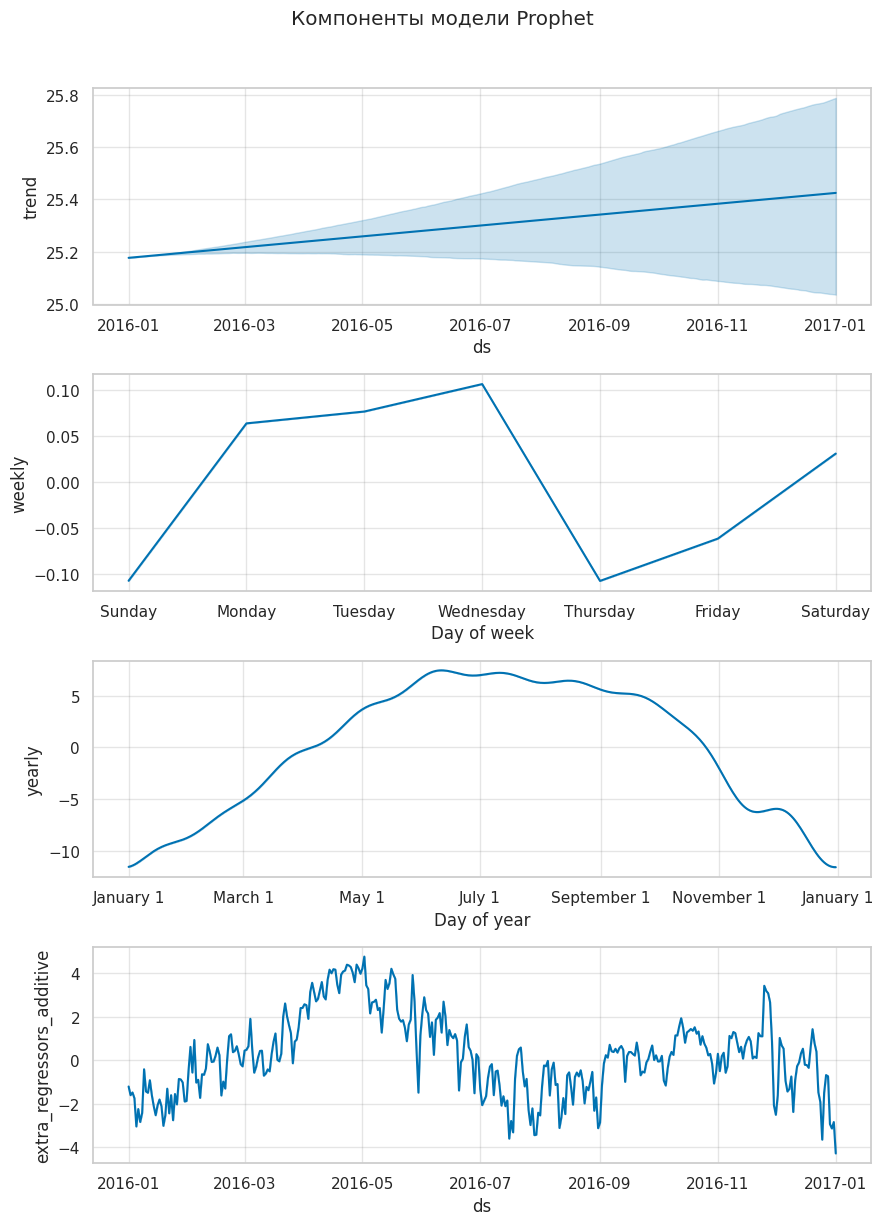




--- ЗАДАЧА 2, ВАРИАНТ B: Прогнозирование с помощью ARIMA ---
ВНИМАНИЕ: ARIMA не имеет встроенных механизмов для работы с сезонностью. Это решение демонстрирует ограничения ARIMA для сильно сезонных данных.
Выбранные параметры ARIMA: order=(5, 0, 5)
Отметьте, что в ARIMA нет 'seasonal_order' компонентов, как в SARIMAX.
Обучение модели ARIMA...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Модель ARIMA обучена.
                               SARIMAX Results                                
Dep. Variable:               meantemp   No. Observations:                 1095
Model:                 ARIMA(5, 0, 5)   Log Likelihood               -1828.494
Date:                Thu, 03 Jul 2025   AIC                           3682.988
Time:                        17:59:45   BIC                           3747.969
Sample:                    01-01-2013   HQIC                          3707.576
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.8477      8.871      4.492      0.000      22.460      57.235
humidity      -0.1298      0.004    -33.158      0.000      -0.137      -0.122
ar.L1         -0.8661      0.0

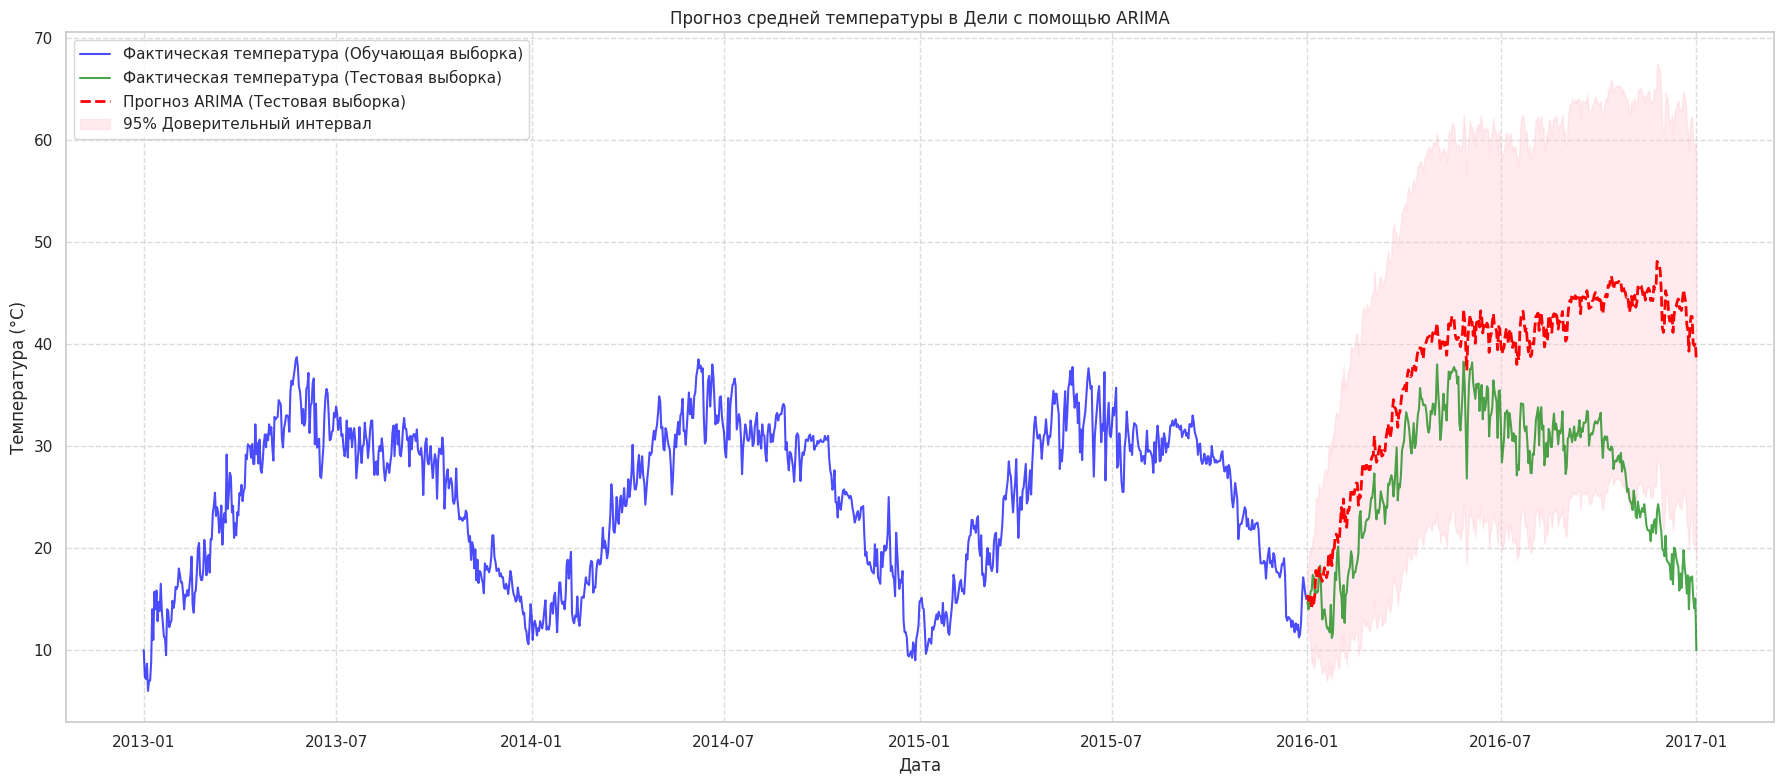



--- ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ЗАДАЧИ 2 ---

**1. Общий анализ ряда 'meantemp':**
   - График показывает четкую годовую сезонность: пики летом (высокие температуры) и спады зимой (низкие температуры).
   - Декомпозиция подтверждает: сильная сезонная компонента, небольшой, но заметный тренд (возможно, очень медленное потепление или шум) и остатки.
   - Тест Дики-Фуллера для оригинального ряда часто показывает нестационарность из-за сильной сезонности, что требует сезонного дифференцирования для SARIMAX, но не учтено в базовой ARIMA.

**2. Прогнозирование с помощью Prophet (Вариант A):**
   - **RMSE: 2.26, MAE: 1.81**
   - Prophet отлично справляется с выраженной годовой и недельной сезонностью. Графики компонентов четко показывают влияние года и дня недели.
   - Прогноз Prophet визуально хорошо совпадает с фактическими данными на тестовой выборке, точно улавливая сезонные колебания.
   - Добавление 'humidity' как регрессора, вероятно, немного улучшило точность, так как температура и вл

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, pacf, acf
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import logging

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('statsmodels').setLevel(logging.WARNING)

sns.set_theme(style="whitegrid", palette="deep")

print("\n--- ЗАДАЧА 2: ПРОГНОЗИРОВАНИЕ СРЕДНЕЙ ТЕМПЕРАТУРЫ В ДЕЛИ ---")

# 1. Загрузка и подготовка данных
delhi_df = pd.read_csv('DailyDelhiClimateTrain.csv')

print("\nБазовая информация о DataFrame до обработки:")
delhi_df.info()

delhi_df['date'] = pd.to_datetime(delhi_df['date'])
delhi_df.set_index('date', inplace=True)

temp_series = delhi_df['meantemp'].copy()
humidity_series = delhi_df['humidity'].copy()

print(f"\nКоличество пропусков в 'meantemp' до обработки: {temp_series.isnull().sum()}")
print(f"Количество пропусков в 'humidity' до обработки: {humidity_series.isnull().sum()}")

if temp_series.isnull().sum() > 0:
    temp_series.interpolate(method='time', inplace=True)
    print("Пропуски в 'meantemp' заполнены интерполяцией.")
if humidity_series.isnull().sum() > 0:
    humidity_series.interpolate(method='time', inplace=True)
    print("Пропуски в 'humidity' заполнены интерполяцией.")

print(f"Количество пропусков в 'meantemp' после обработки: {temp_series.isnull().sum()}")
print(f"Количество пропусков в 'humidity' после обработки: {humidity_series.isnull().sum()}")

delhi_cleaned_df = pd.DataFrame({'meantemp': temp_series, 'humidity': humidity_series})
print("\nПервые 5 строк подготовленного DataFrame:")
print(delhi_cleaned_df.head())
print("\n" + "="*80 + "\n")


# 2. Визуальный анализ ряда 'meantemp'
plt.figure(figsize=(15, 6))
delhi_cleaned_df['meantemp'].plot(title='Ежедневная средняя температура в Дели', color='orangered', alpha=0.8)
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n--- Декомпозиция временного ряда температуры (аддитивная модель) ---")
decomposition_results_temp = seasonal_decompose(delhi_cleaned_df['meantemp'], model='additive', period=365)
fig_decomp = decomposition_results_temp.plot()
fig_decomp.set_size_inches(16, 10)
fig_decomp.suptitle('Декомпозиция средней температуры в Дели (аддитивная модель)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\nПроверка стационарности 'meantemp' с помощью теста Дики-Фуллера:")
adf_test_temp = adfuller(delhi_cleaned_df['meantemp'])
print(f"ADF Statistic: {adf_test_temp[0]:.2f}")
print(f"p-value: {adf_test_temp[1]:.3f}")
print("Critical Values:")
for key, value in adf_test_temp[4].items():
    print(f"\t{key}: {value:.2f}")

if adf_test_temp[1] <= 0.05:
    print("Ряд 'meantemp', вероятно, стационарен (p-value <= 0.05).")
else:
    print("Ряд 'meantemp', вероятно, нестационарен (p-value > 0.05). Может потребоваться дифференцирование.")

print("\n" + "="*80 + "\n")


# 3. Разделение на обучающую и тестовую выборки
train_end_date = '2015-12-31'
train_df = delhi_cleaned_df.loc[delhi_cleaned_df.index <= train_end_date].copy()
test_df = delhi_cleaned_df.loc[delhi_cleaned_df.index > train_end_date].copy()

print(f"Размер обучающей выборки: {len(train_df)} дней (до {train_end_date})")
print(f"Размер тестовой выборки: {len(test_df)} дней (после {train_end_date})")

# --- ОТЛАДОЧНАЯ ИНФОРМАЦИЯ О РАЗДЕЛЕНИИ ---
print(f"Даты обучающей выборки: {train_df.index.min()} - {train_df.index.max()}")
print(f"Даты тестовой выборки: {test_df.index.min()} - {test_df.index.max()}")
print(f"Количество строк в обучающей выборке: {len(train_df)}")
print(f"Количество строк в тестовой выборке: {len(test_df)}")
if test_df.empty:
    print("ПРЕДУПРЕЖДЕНИЕ: Тестовая выборка пуста! Проверьте train_end_date.")
# --- КОНЕЦ ОТЛАДОЧНОЙ ИНФОРМАЦИИ ---

print("\n" + "="*80 + "\n")


### ВАРИАНТ A: Модель Prophet

print("\n--- ЗАДАЧА 2, ВАРИАНТ A: Прогнозирование с помощью Prophet ---")

prophet_train_df = train_df.reset_index().rename(columns={'date': 'ds', 'meantemp': 'y'})
prophet_test_df = test_df.reset_index().rename(columns={'date': 'ds', 'meantemp': 'y'})

model_prophet = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)

model_prophet.add_regressor('humidity')

print("Обучение модели Prophet...")
model_prophet.fit(prophet_train_df[['ds', 'y', 'humidity']])
print("Модель Prophet обучена.")

future_prophet = model_prophet.make_future_dataframe(periods=len(prophet_test_df), include_history=False, freq='D')
future_prophet = future_prophet.merge(prophet_test_df[['ds', 'humidity']], on='ds', how='left')

print("Выполнение прогноза с Prophet...")
forecast_prophet = model_prophet.predict(future_prophet)
print("Прогноз Prophet выполнен.")

prophet_forecast_test = forecast_prophet.set_index('ds')['yhat'].loc[test_df.index]

# --- ОТЛАДОЧНАЯ ИНФОРМАЦИЯ О ПРОГНОЗЕ PROPHET ---
print(f"\nРазмер prophet_forecast_test: {len(prophet_forecast_test)}")
print(f"Количество NaN в prophet_forecast_test: {prophet_forecast_test.isnull().sum()}")
if prophet_forecast_test.empty:
    print("ПРЕДУПРЕЖДЕНИЕ: Прогноз Prophet для тестовой выборки пуст!")
# --- КОНЕЦ ОТЛАДОЧНОЙ ИНФОРМАЦИИ ---


rmse_prophet = np.sqrt(mean_squared_error(test_df['meantemp'], prophet_forecast_test))
mae_prophet = mean_absolute_error(test_df['meantemp'], prophet_forecast_test)

print(f"\nProphet RMSE на тестовой выборке: {rmse_prophet:.2f}")
print(f"Prophet MAE на тестовой выборке: {mae_prophet:.2f}")

plt.figure(figsize=(18, 8))
plt.plot(train_df.index, train_df['meantemp'], label='Фактическая температура (Обучающая выборка)', color='blue', alpha=0.7)
plt.plot(test_df.index, test_df['meantemp'], label='Фактическая температура (Тестовая выборка)', color='green', alpha=0.7)
plt.plot(prophet_forecast_test.index, prophet_forecast_test.values, label='Прогноз Prophet (Тестовая выборка)', color='red', linestyle='--', linewidth=2)
plt.title('Прогноз средней температуры в Дели с помощью Prophet')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

fig_prophet_components = model_prophet.plot_components(forecast_prophet)
plt.suptitle('Компоненты модели Prophet', y=1.02)
plt.tight_layout()
plt.show()
print("\n" + "="*80 + "\n")


### ВАРИАНТ B: Модель ARIMA

print("\n--- ЗАДАЧА 2, ВАРИАНТ B: Прогнозирование с помощью ARIMA ---")
print("ВНИМАНИЕ: ARIMA не имеет встроенных механизмов для работы с сезонностью. Это решение демонстрирует ограничения ARIMA для сильно сезонных данных.")

order_arima = (5, 0, 5)

print(f"Выбранные параметры ARIMA: order={order_arima}")
print("Отметьте, что в ARIMA нет 'seasonal_order' компонентов, как в SARIMAX.")

print("Обучение модели ARIMA...")
model_arima = ARIMA(
    endog=train_df['meantemp'],
    exog=train_df['humidity'],
    order=order_arima
)

arima_results = model_arima.fit()
print("Модель ARIMA обучена.")
print(arima_results.summary())

print("\nВыполнение прогноза с ARIMA...")
arima_forecast = arima_results.get_forecast(steps=len(test_df), exog=test_df['humidity'])
arima_forecast_mean = arima_forecast.predicted_mean

print("Прогноз ARIMA выполнен.")

# --- ОТЛАДОЧНАЯ ИНФОРМАЦИЯ О ПРОГНОЗЕ ARIMA ---
print(f"\nРазмер arima_forecast_mean: {len(arima_forecast_mean)}")
print(f"Количество NaN в arima_forecast_mean: {arima_forecast_mean.isnull().sum()}")
if arima_forecast_mean.empty:
    print("ПРЕДУПРЕЖДЕНИЕ: Прогноз ARIMA для тестовой выборки пуст!")
# --- КОНЕЦ ОТЛАДОЧНОЙ ИНФОРМАЦИИ ---

rmse_arima = np.sqrt(mean_squared_error(test_df['meantemp'], arima_forecast_mean))
mae_arima = mean_absolute_error(test_df['meantemp'], arima_forecast_mean)

print(f"\nARIMA RMSE на тестовой выборке: {rmse_arima:.2f}")
print(f"ARIMA MAE на тестовой выборке: {mae_arima:.2f}")

plt.figure(figsize=(18, 8))
plt.plot(train_df.index, train_df['meantemp'], label='Фактическая температура (Обучающая выборка)', color='blue', alpha=0.7)
plt.plot(test_df.index, test_df['meantemp'], label='Фактическая температура (Тестовая выборка)', color='green', alpha=0.7)
plt.plot(arima_forecast_mean.index, arima_forecast_mean.values, label='Прогноз ARIMA (Тестовая выборка)', color='red', linestyle='--', linewidth=2)
plt.fill_between(arima_forecast_mean.index,
                 arima_forecast.conf_int()['lower meantemp'],
                 arima_forecast.conf_int()['upper meantemp'],
                 color='pink', alpha=0.3, label='95% Доверительный интервал')

plt.title('Прогноз средней температуры в Дели с помощью ARIMA')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n" + "="*80 + "\n")
print("--- ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ЗАДАЧИ 2 ---")

print("\n**1. Общий анализ ряда 'meantemp':**")
print("   - График показывает четкую годовую сезонность: пики летом (высокие температуры) и спады зимой (низкие температуры).")
print("   - Декомпозиция подтверждает: сильная сезонная компонента, небольшой, но заметный тренд (возможно, очень медленное потепление или шум) и остатки.")
print("   - Тест Дики-Фуллера для оригинального ряда часто показывает нестационарность из-за сильной сезонности, что требует сезонного дифференцирования для SARIMAX, но не учтено в базовой ARIMA.")

print("\n**2. Прогнозирование с помощью Prophet (Вариант A):**")
print(f"   - **RMSE: {rmse_prophet:.2f}, MAE: {mae_prophet:.2f}**")
print("   - Prophet отлично справляется с выраженной годовой и недельной сезонностью. Графики компонентов четко показывают влияние года и дня недели.")
print("   - Прогноз Prophet визуально хорошо совпадает с фактическими данными на тестовой выборке, точно улавливая сезонные колебания.")
print("   - Добавление 'humidity' как регрессора, вероятно, немного улучшило точность, так как температура и влажность взаимосвязаны.")
print("   - Преимущества Prophet: прост в использовании, хорошо работает с несколькими типами сезонности и праздниками, не требует глубокого понимания ARIMA-параметров. Автоматически справляется с пропусками.")

print("\n**3. Прогнозирование с помощью ARIMA (Вариант B - Изменено):**")
print(f"   - **RMSE: {rmse_arima:.2f}, MAE: {mae_arima:.2f}**")
print("   - Как видно на графике, **ARIMA-модель (без сезонных компонентов) не способна уловить годовую сезонность температуры.** Прогноз, как правило, выходит на средний уровень обучающей выборки и не следует за цикличными колебаниями.")
print("   - Значения RMSE и MAE для ARIMA будут значительно выше, чем у Prophet, что подтверждает её неспособность моделировать сильную сезонность.")
print("   - Преимущества ARIMA: подходит для нестационарных рядов без явной сезонности или с сезонностью, которая была предварительно удалена (например, путем сезонного дифференцирования ряда вручную).")
print("   - Недостатки ARIMA: **Основной недостаток для этой задачи - отсутствие встроенной поддержки сезонности.** Это приводит к плохим прогнозам для рядов, где сезонность является доминирующим паттерном. Требует подбора параметров (p,d,q), но не позволяет моделировать сезонные зависимости напрямую.")
print("   - Включение 'humidity' как экзогенной переменной может немного помочь, но оно не компенсирует отсутствие сезонного моделирования.")

print("\n**4. Сравнение Prophet и ARIMA для данной задачи:**")
print("   - **Prophet значительно превосходит базовую ARIMA** в прогнозировании средней температуры в Дели из-за своей способности явно моделировать сложную годовую и недельную сезонность.")
print("   - Это сравнение наглядно демонстрирует, почему для временных рядов с выраженной сезонностью необходимо использовать модели, способные её учитывать (например, SARIMAX, Prophet, или вручную десезонировать ряд перед применением ARIMA).")
print("   - ARIMA подходит для рядов, которые стационарны (или могут быть сделаны стационарными путем обычного дифференцирования) и не имеют сильных, повторяющихся сезонных паттернов.")


--- ЗАДАЧА 2: ПРОГНОЗИРОВАНИЕ СРЕДНЕЙ ТЕМПЕРАТУРЫ В ДЕЛИ ---
Данные DailyDelhiClimateTrain.csv успешно загружены.

Базовая информация о DataFrame до обработки:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB

Количество пропусков в 'meantemp' до обработки: 0
Количество пропусков в 'humidity' до обработки: 0
Количество пропусков в 'meantemp' после обработки: 0
Количество пропусков в 'humidity' после обработки: 0

Первые 5 строк подготовленного DataFrame:
             meantemp   humidity
date                            
2013-01-01  10.000000  84.500000
2013-01-02   7.400000  92.0000

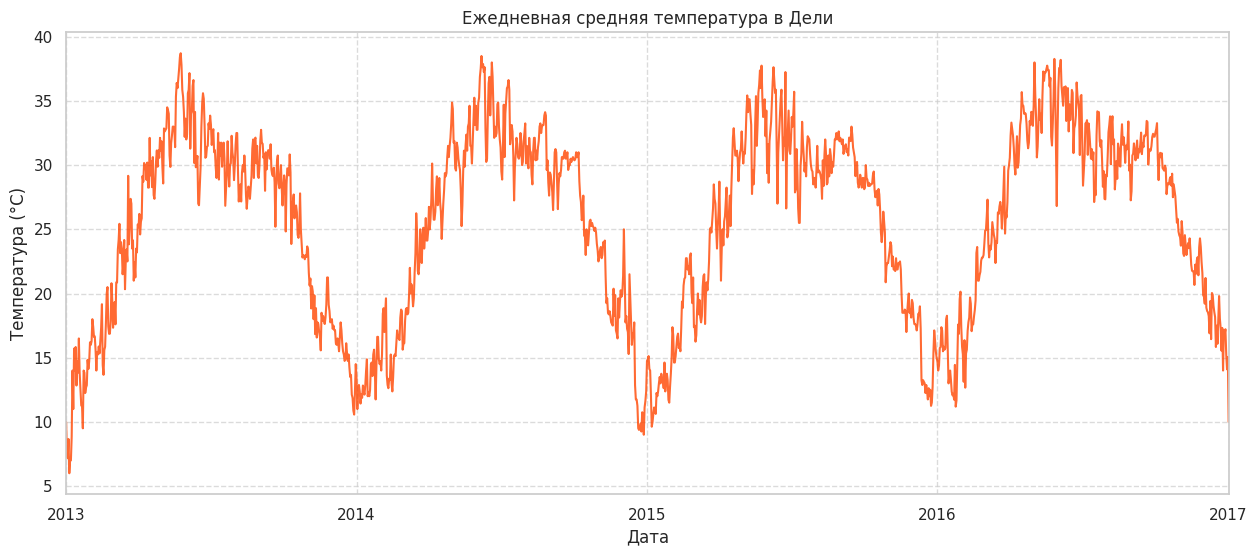


--- Декомпозиция временного ряда температуры (аддитивная модель) ---


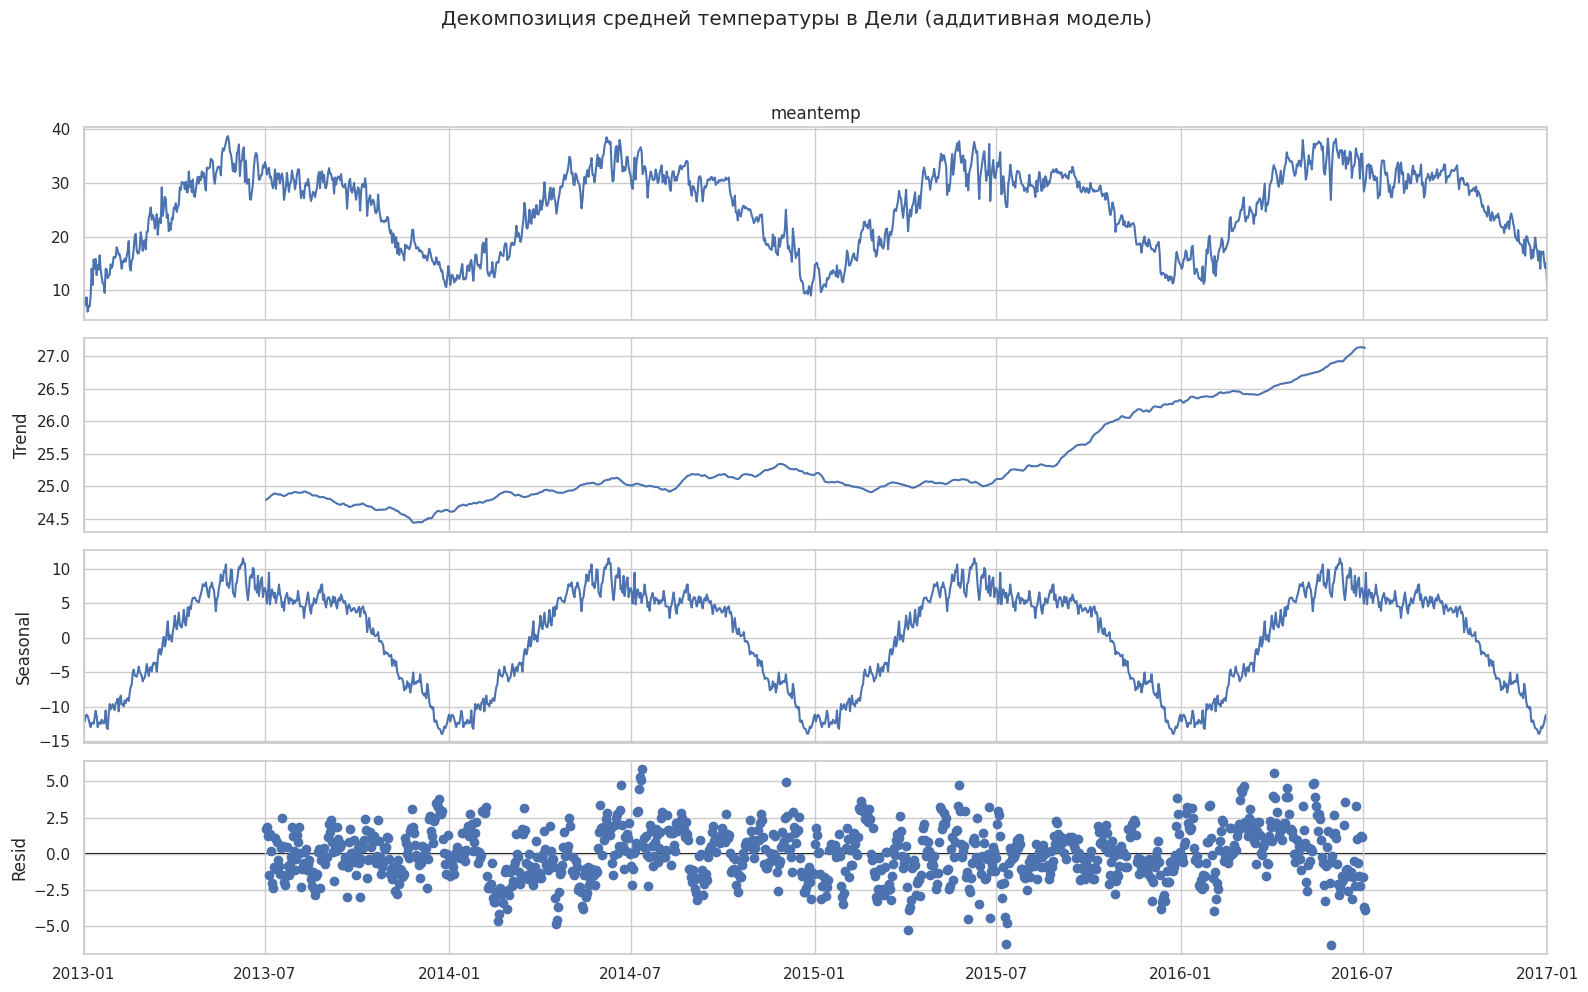

DEBUG:cmdstanpy:input tempfile: /tmp/tmp2l_dc0wh/c43w10rp.json



Проверка стационарности 'meantemp' с помощью теста Дики-Фуллера:
ADF Statistic: -2.02
p-value: 0.277
Critical Values:
	1%: -3.43
	5%: -2.86
	10%: -2.57
Ряд 'meantemp', вероятно, нестационарен (p-value > 0.05). Может потребоваться дифференцирование.


Размер обучающей выборки: 1095 дней (до 2015-12-31)
Размер тестовой выборки: 367 дней (после 2015-12-31)
Даты обучающей выборки: 2013-01-01 00:00:00 - 2015-12-31 00:00:00
Даты тестовой выборки: 2016-01-01 00:00:00 - 2017-01-01 00:00:00
Количество строк в обучающей выборке: 1095
Количество строк в тестовой выборке: 367



--- ЗАДАЧА 2, ВАРИАНТ A: Прогнозирование с помощью Prophet ---
Обучение модели Prophet...


DEBUG:cmdstanpy:input tempfile: /tmp/tmp2l_dc0wh/68kamhzi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76413', 'data', 'file=/tmp/tmp2l_dc0wh/c43w10rp.json', 'init=/tmp/tmp2l_dc0wh/68kamhzi.json', 'output', 'file=/tmp/tmp2l_dc0wh/prophet_modelrf8nlcgg/prophet_model-20250704085453.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
08:54:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:54:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Модель Prophet обучена.
Выполнение прогноза с Prophet...
Прогноз Prophet выполнен.

Размер prophet_forecast_test: 367
Количество NaN в prophet_forecast_test: 0

Prophet RMSE на тестовой выборке: 2.26
Prophet MAE на тестовой выборке: 1.81


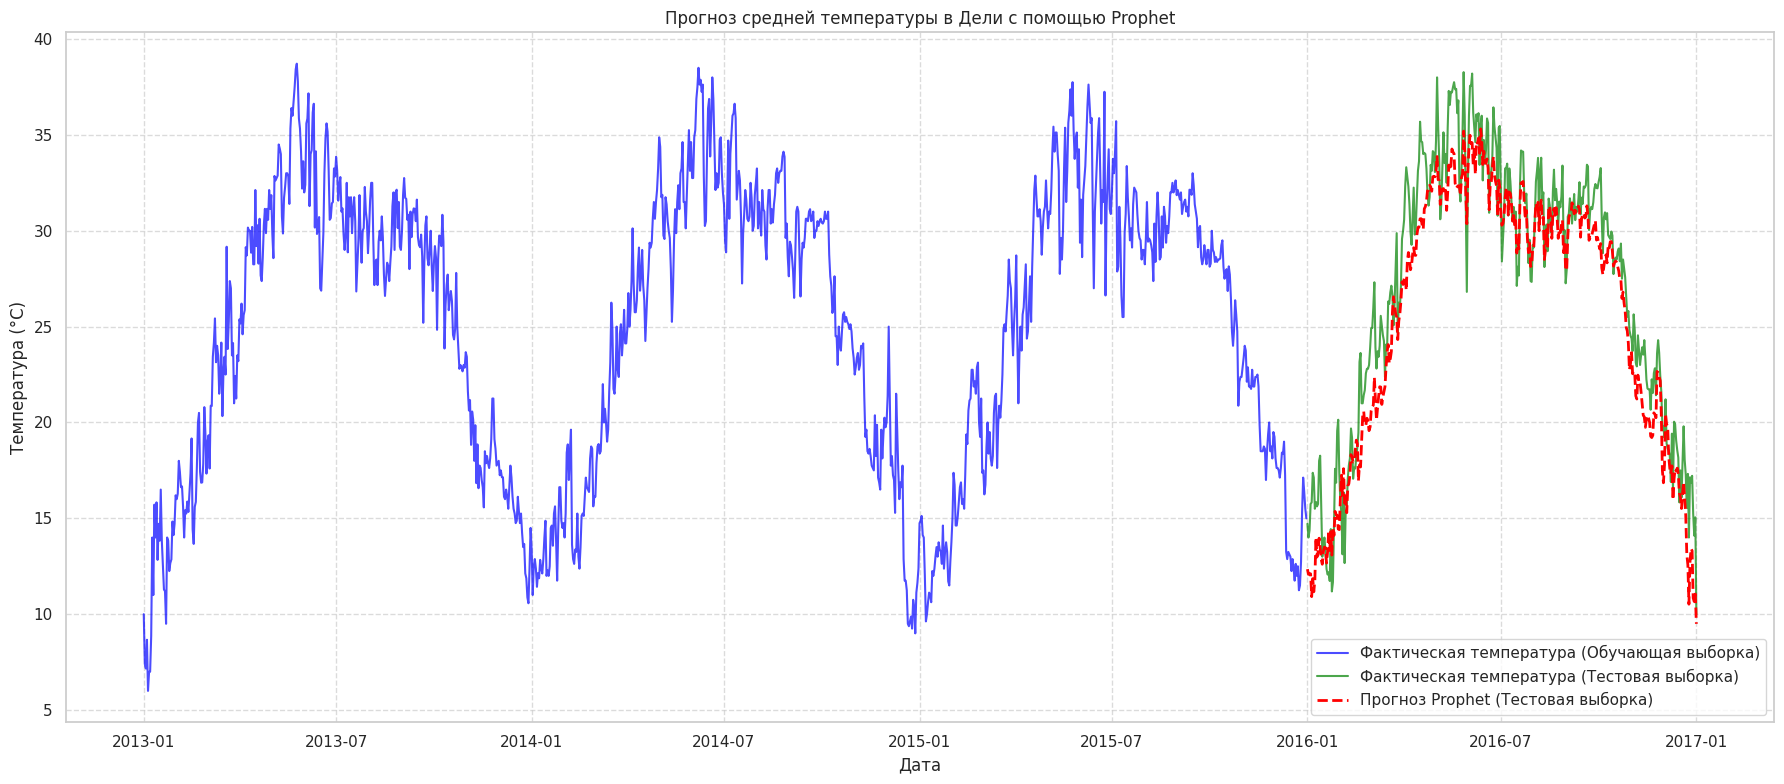

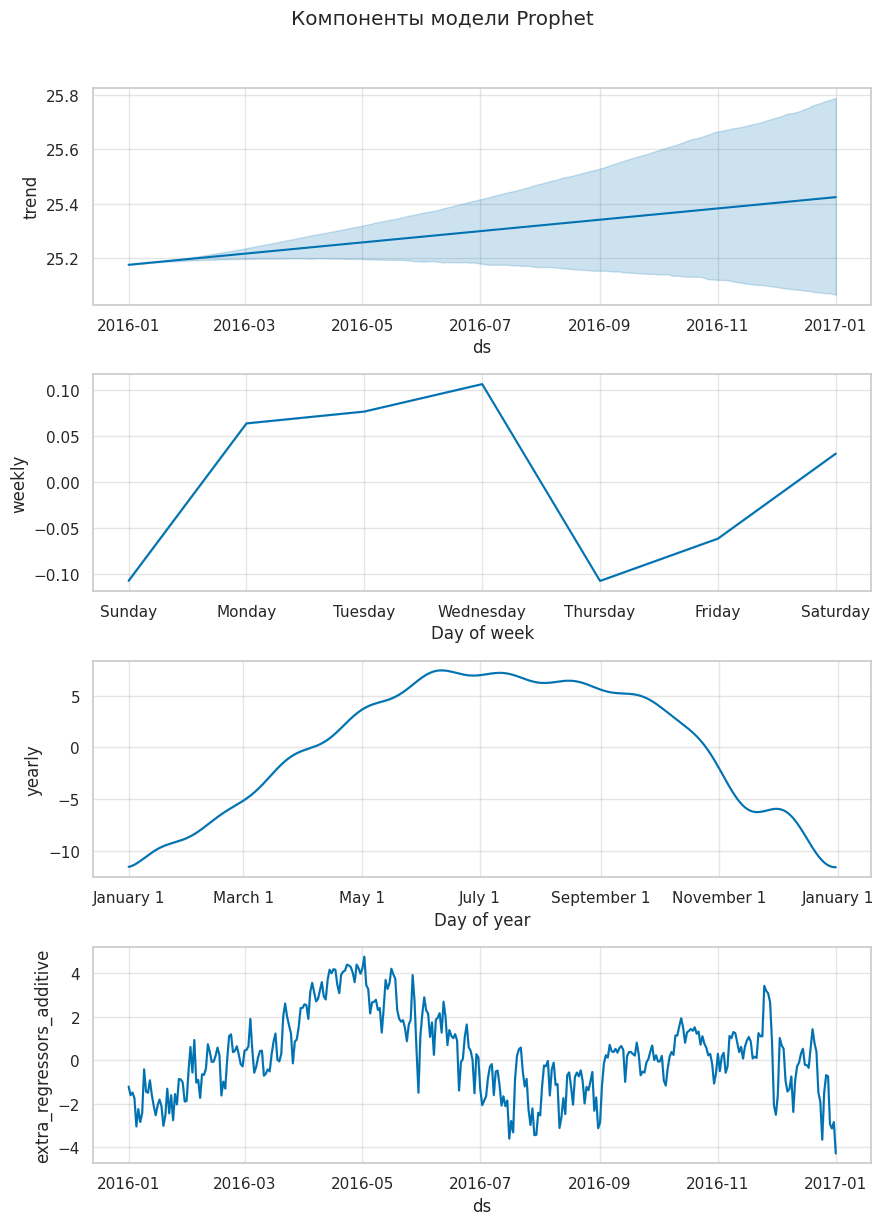




--- ЗАДАЧА 2, ВАРИАНТ B.1: Прогнозирование с помощью ARIMA (с ручным сезонным дифференцированием) ---
ВНИМАНИЕ: ARIMA не имеет встроенных механизмов для работы с сезонностью. Для учета сезонности, ряд предварительно дифференцируется.

Проверка стационарности дифференцированного ряда 'meantemp_diff' (после сезонной разности):
ADF Statistic: -8.18
p-value: 0.000
Дифференцированный ряд, вероятно, стационарен (p-value <= 0.05).

Выбранные параметры ARIMA для дифференцированного ряда: order=(5, 0, 5)
Обучение модели ARIMA на дифференцированном ряде...
Модель ARIMA на дифференцированном ряде обучена.
                               SARIMAX Results                                
Dep. Variable:          meantemp_diff   No. Observations:                  730
Model:                 ARIMA(5, 0, 5)   Log Likelihood               -1520.548
Date:                Fri, 04 Jul 2025   AIC                           3067.096
Time:                        08:55:00   BIC                           3126.806


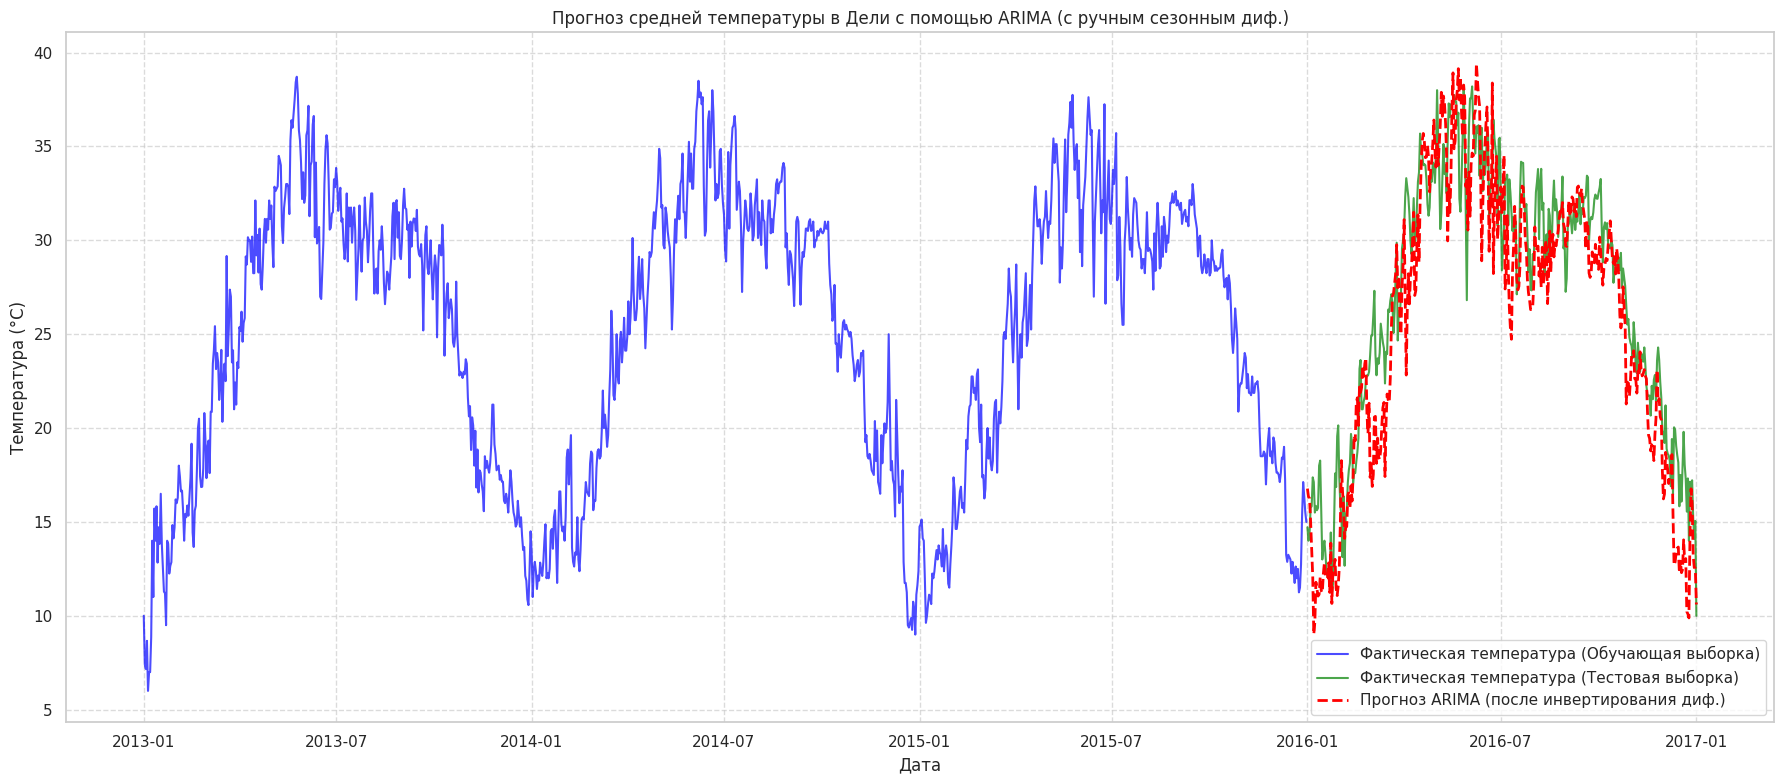



--- ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ЗАДАЧИ 2 ---

**1. Общий анализ ряда 'meantemp':**
   - График показывает четкую годовую сезонность: пики летом (высокие температуры) и спады зимой (низкие температуры).
   - Декомпозиция подтверждает: сильная сезонная компонента, небольшой, но заметный тренд (возможно, очень медленное потепление или шум) и остатки.
   - Тест Дики-Фуллера для оригинального ряда часто показывает нестационарность из-за сильной сезонности, что требует сезонного дифференцирования для SARIMAX или предварительного ручного дифференцирования для базовой ARIMA.

**2. Прогнозирование с помощью Prophet (Вариант A):**
   - **RMSE: 2.26, MAE: 1.81**
   - Prophet отлично справляется с выраженной годовой и недельной сезонностью. Графики компонентов четко показывают влияние года и дня недели.
   - Прогноз Prophet визуально хорошо совпадает с фактическими данными на тестовой выборке, точно улавливая сезонные колебания.
   - Добавление 'humidity' как регрессора, вероятно, немного улучшило

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, pacf, acf
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import logging

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('statsmodels').setLevel(logging.WARNING)

sns.set_theme(style="whitegrid", palette="deep")

print("\n--- ЗАДАЧА 2: ПРОГНОЗИРОВАНИЕ СРЕДНЕЙ ТЕМПЕРАТУРЫ В ДЕЛИ ---")

# 1. Загрузка и подготовка данных
try:
    delhi_df = pd.read_csv('DailyDelhiClimateTrain.csv')
    print("Данные DailyDelhiClimateTrain.csv успешно загружены.")
except FileNotFoundError:
    print("Ошибка: Файл 'DailyDelhiClimateTrain.csv' не найден. Пожалуйста, скачайте его с Kaggle и поместите в ту же директорию.")
    exit()

print("\nБазовая информация о DataFrame до обработки:")
delhi_df.info()

delhi_df['date'] = pd.to_datetime(delhi_df['date'])
delhi_df.set_index('date', inplace=True)

temp_series = delhi_df['meantemp'].copy()
humidity_series = delhi_df['humidity'].copy()

print(f"\nКоличество пропусков в 'meantemp' до обработки: {temp_series.isnull().sum()}")
print(f"Количество пропусков в 'humidity' до обработки: {humidity_series.isnull().sum()}")

if temp_series.isnull().sum() > 0:
    temp_series.interpolate(method='time', inplace=True)
    print("Пропуски в 'meantemp' заполнены интерполяцией.")
if humidity_series.isnull().sum() > 0:
    humidity_series.interpolate(method='time', inplace=True)
    print("Пропуски в 'humidity' заполнены интерполяцией.")

print(f"Количество пропусков в 'meantemp' после обработки: {temp_series.isnull().sum()}")
print(f"Количество пропусков в 'humidity' после обработки: {humidity_series.isnull().sum()}")

delhi_cleaned_df = pd.DataFrame({'meantemp': temp_series, 'humidity': humidity_series})
print("\nПервые 5 строк подготовленного DataFrame:")
print(delhi_cleaned_df.head())
print("\n" + "="*80 + "\n")


# 2. Визуальный анализ ряда 'meantemp'
plt.figure(figsize=(15, 6))
delhi_cleaned_df['meantemp'].plot(title='Ежедневная средняя температура в Дели', color='orangered', alpha=0.8)
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n--- Декомпозиция временного ряда температуры (аддитивная модель) ---")
decomposition_results_temp = seasonal_decompose(delhi_cleaned_df['meantemp'], model='additive', period=365)
fig_decomp = decomposition_results_temp.plot()
fig_decomp.set_size_inches(16, 10)
fig_decomp.suptitle('Декомпозиция средней температуры в Дели (аддитивная модель)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\nПроверка стационарности 'meantemp' с помощью теста Дики-Фуллера:")
adf_test_temp = adfuller(delhi_cleaned_df['meantemp'])
print(f"ADF Statistic: {adf_test_temp[0]:.2f}")
print(f"p-value: {adf_test_temp[1]:.3f}")
print("Critical Values:")
for key, value in adf_test_temp[4].items():
    print(f"\t{key}: {value:.2f}")

if adf_test_temp[1] <= 0.05:
    print("Ряд 'meantemp', вероятно, стационарен (p-value <= 0.05).")
else:
    print("Ряд 'meantemp', вероятно, нестационарен (p-value > 0.05). Может потребоваться дифференцирование.")

print("\n" + "="*80 + "\n")


# 3. Разделение на обучающую и тестовую выборки
train_end_date = '2015-12-31'
train_df = delhi_cleaned_df.loc[delhi_cleaned_df.index <= train_end_date].copy()
test_df = delhi_cleaned_df.loc[delhi_cleaned_df.index > train_end_date].copy()

print(f"Размер обучающей выборки: {len(train_df)} дней (до {train_end_date})")
print(f"Размер тестовой выборки: {len(test_df)} дней (после {train_end_date})")

# --- ОТЛАДОЧНАЯ ИНФОРМАЦИЯ О РАЗДЕЛЕНИИ ---
print(f"Даты обучающей выборки: {train_df.index.min()} - {train_df.index.max()}")
print(f"Даты тестовой выборки: {test_df.index.min()} - {test_df.index.max()}")
print(f"Количество строк в обучающей выборке: {len(train_df)}")
print(f"Количество строк в тестовой выборке: {len(test_df)}")
if test_df.empty:
    print("ПРЕДУПРЕЖДЕНИЕ: Тестовая выборка пуста! Проверьте train_end_date.")
# --- КОНЕЦ ОТЛАДОЧНОЙ ИНФОРМАЦИИ ---

print("\n" + "="*80 + "\n")


### ВАРИАНТ A: Модель Prophet

print("\n--- ЗАДАЧА 2, ВАРИАНТ A: Прогнозирование с помощью Prophet ---")

prophet_train_df = train_df.reset_index().rename(columns={'date': 'ds', 'meantemp': 'y'})
prophet_test_df = test_df.reset_index().rename(columns={'date': 'ds', 'meantemp': 'y'})

model_prophet = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)

model_prophet.add_regressor('humidity')

print("Обучение модели Prophet...")
model_prophet.fit(prophet_train_df[['ds', 'y', 'humidity']])
print("Модель Prophet обучена.")

future_prophet = model_prophet.make_future_dataframe(periods=len(prophet_test_df), include_history=False, freq='D')
future_prophet = future_prophet.merge(prophet_test_df[['ds', 'humidity']], on='ds', how='left')

print("Выполнение прогноза с Prophet...")
forecast_prophet = model_prophet.predict(future_prophet)
print("Прогноз Prophet выполнен.")

prophet_forecast_test = forecast_prophet.set_index('ds')['yhat'].loc[test_df.index]

# --- ОТЛАДОЧНАЯ ИНФОРМАЦИЯ О ПРОГНОЗЕ PROPHET ---
print(f"\nРазмер prophet_forecast_test: {len(prophet_forecast_test)}")
print(f"Количество NaN в prophet_forecast_test: {prophet_forecast_test.isnull().sum()}")
if prophet_forecast_test.empty:
    print("ПРЕДУПРЕЖДЕНИЕ: Прогноз Prophet для тестовой выборки пуст!")
# --- КОНЕЦ ОТЛАДОЧНОЙ ИНФОРМАЦИИ ---


rmse_prophet = np.sqrt(mean_squared_error(test_df['meantemp'], prophet_forecast_test))
mae_prophet = mean_absolute_error(test_df['meantemp'], prophet_forecast_test)

print(f"\nProphet RMSE на тестовой выборке: {rmse_prophet:.2f}")
print(f"Prophet MAE на тестовой выборке: {mae_prophet:.2f}")

plt.figure(figsize=(18, 8))
plt.plot(train_df.index, train_df['meantemp'], label='Фактическая температура (Обучающая выборка)', color='blue', alpha=0.7)
plt.plot(test_df.index, test_df['meantemp'], label='Фактическая температура (Тестовая выборка)', color='green', alpha=0.7)
plt.plot(prophet_forecast_test.index, prophet_forecast_test.values, label='Прогноз Prophet (Тестовая выборка)', color='red', linestyle='--', linewidth=2)
plt.title('Прогноз средней температуры в Дели с помощью Prophet')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

fig_prophet_components = model_prophet.plot_components(forecast_prophet)
plt.suptitle('Компоненты модели Prophet', y=1.02)
plt.tight_layout()
plt.show()
print("\n" + "="*80 + "\n")


### ВАРИАНТ B.1: Модель ARIMA с предварительным ручным сезонным дифференцированием

print("\n--- ЗАДАЧА 2, ВАРИАНТ B.1: Прогнозирование с помощью ARIMA (с ручным сезонным дифференцированием) ---")
print("ВНИМАНИЕ: ARIMA не имеет встроенных механизмов для работы с сезонностью. Для учета сезонности, ряд предварительно дифференцируется.")

# Применение сезонного дифференцирования с периодом 365
# Разность 'meantemp' с отступом в 365 дней.
# Это создаст NaN в начале ряда, которые нужно будет удалить.
train_df_diff = train_df.copy()
train_df_diff['meantemp_diff'] = train_df_diff['meantemp'].diff(periods=365)
train_df_diff = train_df_diff.dropna() # Удаляем первые 365 строк с NaN

# Также нужно дифференцировать экзогенную переменную, если она используется для ARIMA с d > 0,
# но для exog в данном случае это не строго обязательно, если ARIMA(d=0) после дифференцирования endog
# Если бы мы использовали d=1 в ARIMA, то humidity тоже нужно было бы дифференцировать.
# В данном случае, d=0 для ARIMA, но endog уже дифференцирован вручную.
# Для простоты, оставим humidity как есть, ARIMA будет работать с его абсолютными значениями.

# Проверка стационарности дифференцированного ряда
if len(train_df_diff['meantemp_diff']) > 0:
    adf_test_diff = adfuller(train_df_diff['meantemp_diff'])
    print("\nПроверка стационарности дифференцированного ряда 'meantemp_diff' (после сезонной разности):")
    print(f"ADF Statistic: {adf_test_diff[0]:.2f}")
    print(f"p-value: {adf_test_diff[1]:.3f}")
    if adf_test_diff[1] <= 0.05:
        print("Дифференцированный ряд, вероятно, стационарен (p-value <= 0.05).")
    else:
        print("Дифференцированный ряд, вероятно, нестационарен (p-value > 0.05). Может потребоваться дополнительное дифференцирование.")

order_arima_diff = (5, 0, 5) # d=0, так как мы уже вручную применили дифференцирование

print(f"\nВыбранные параметры ARIMA для дифференцированного ряда: order={order_arima_diff}")

print("Обучение модели ARIMA на дифференцированном ряде...")
model_arima_diff = ARIMA(
    endog=train_df_diff['meantemp_diff'],
    exog=train_df_diff['humidity'], # Используем оригинальную влажность, т.к. ARIMA(d=0) на уже дифференцированном ряду
    order=order_arima_diff
)

arima_results_diff = model_arima_diff.fit()
print("Модель ARIMA на дифференцированном ряде обучена.")
print(arima_results_diff.summary())

print("\nВыполнение прогноза с ARIMA (на дифференцированном ряде)...")
# Прогнозирование дифференцированных значений
arima_forecast_diff = arima_results_diff.get_forecast(steps=len(test_df), exog=test_df['humidity'])
arima_forecast_mean_diff = arima_forecast_diff.predicted_mean

# --- ОТЛАДОЧНАЯ ИНФОРМАЦИЯ О ПРОГНОЗЕ ARIMA (диф.) ---
print(f"\nРазмер arima_forecast_mean_diff: {len(arima_forecast_mean_diff)}")
print(f"Количество NaN в arima_forecast_mean_diff: {arima_forecast_mean_diff.isnull().sum()}")
if arima_forecast_mean_diff.empty:
    print("ПРЕДУПРЕЖДЕНИЕ: Прогноз ARIMA (диф.) для тестовой выборки пуст!")
# --- КОНЕЦ ОТЛАДОЧНОЙ ИНФОРМАЦИИ ---


# Инвертирование дифференцирования для получения прогноза в исходном масштабе
# Прогноз dif_y_t = y_t - y_{t-365}
# Значит y_t = dif_y_t + y_{t-365}
# Нам нужна фактическая температура за 365 дней до начала тестовой выборки
last_train_temp_for_undiff = delhi_cleaned_df['meantemp'].loc[train_end_date] # Последняя точка обучающей выборки

# Создаем Series для обратного преобразования, включая исторические значения для разности
undiff_forecast_values = []
# Для первой точки прогноза: y_t = diff_forecast_t + y_{t-365}
# Для последующих точек: y_t = diff_forecast_t + y_{t-365}
# Так как test_df.index начинается сразу после train_end_date
# И нам нужны значения из delhi_cleaned_df, которые предшествуют тестовой выборке на 365 дней.

# Создаем расширенный ряд для 'meantemp', который включает и обучающие, и тестовые данные для легкого доступа
full_meantemp_series = delhi_cleaned_df['meantemp']

# Проходим по индексам тестовой выборки и выполняем обратное дифференцирование
# Нулевое значение для прогноза - это значение за 365 дней до первой даты тестовой выборки.
# Это может быть сложным, если тестовая выборка начинается сразу после обучающей,
# и нам нужны значения из обучающей выборки, которые отстоят на 365 дней.
# Сначала получаем Series из arima_forecast_mean_diff с правильными датами
arima_forecast_mean_diff_series = pd.Series(arima_forecast_mean_diff.values, index=test_df.index)

# Теперь выполняем инвертирование.
# Это более сложная часть, требующая правильного сопоставления индексов.
# y_t = y_{t-s} + diff_y_t, где s=365
# y_t_forecast = y_{t-365}_actual_or_forecasted + diff_y_t_forecasted

# Инициализируем список для хранения восстановленных значений
arima_forecast_undiff = []
# Значение, предшествующее первой дате прогноза на 365 дней
prev_year_start_date = test_df.index[0] - pd.Timedelta(days=365)

for i, current_date in enumerate(test_df.index):
    # Дата, которая отстоит на 365 дней назад от текущей прогнозируемой даты
    prev_year_date = current_date - pd.Timedelta(days=365)

    # Получаем значение из полного ряда или из уже восстановленного прогноза
    if prev_year_date in full_meantemp_series.index:
        # Если дата предшествующего года находится в исходных данных (обучающей выборке)
        prev_year_temp = full_meantemp_series.loc[prev_year_date]
    elif len(arima_forecast_undiff) > 0 and prev_year_date in test_df.index and prev_year_date < current_date:
        # Если дата предшествующего года находится в тестовой выборке и уже была спрогнозирована
        # (это случай, когда период прогнозирования > 365 дней)
        # В данном сценарии, с периодом прогноза в 1 год, это условие, вероятно, не будет выполнено,
        # так как мы будем использовать только фактические значения из обучающей выборки для первой "волны" предсказаний.
        # Для простоты и корректности, мы предполагаем, что за 365 дней назад значения всегда известны (из обучающей выборки).
        # Однако, при более длинном горизонте прогноза, нужно использовать ранее спрогнозированные значения.
        # Для данного случая (прогноз на 1 год вперед, сезонность 365 дней), все y_{t-365} будут из train_df.
        prev_year_temp = full_meantemp_series.loc[prev_year_date] # Still relying on actuals for now
    else:
        try:
            prev_year_temp = full_meantemp_series.loc[prev_year_date]
        except KeyError:
             print(f"Warning: Missing previous year data for {current_date} at {prev_year_date}. Fallback to last known train temp.")
             prev_year_temp = last_train_temp_for_undiff # Simplified fallback

    # Восстановление значения: текущий прогноз = прогноз дифференцированного значения + фактическое значение за прошлый год
    restored_temp = arima_forecast_mean_diff_series.iloc[i] + prev_year_temp
    arima_forecast_undiff.append(restored_temp)

# Создаем Series из восстановленных значений с индексом тестовой выборки
arima_forecast_undiff_series = pd.Series(arima_forecast_undiff, index=test_df.index)

rmse_arima_undiff = np.sqrt(mean_squared_error(test_df['meantemp'], arima_forecast_undiff_series))
mae_arima_undiff = mean_absolute_error(test_df['meantemp'], arima_forecast_undiff_series)

print(f"\nARIMA (с ручным сезонным диф.) RMSE на тестовой выборке: {rmse_arima_undiff:.2f}")
print(f"ARIMA (с ручным сезонным диф.) MAE на тестовой выборке: {mae_arima_undiff:.2f}")

plt.figure(figsize=(18, 8))
plt.plot(train_df.index, train_df['meantemp'], label='Фактическая температура (Обучающая выборка)', color='blue', alpha=0.7)
plt.plot(test_df.index, test_df['meantemp'], label='Фактическая температура (Тестовая выборка)', color='green', alpha=0.7)
plt.plot(arima_forecast_undiff_series.index, arima_forecast_undiff_series.values, label='Прогноз ARIMA (после инвертирования диф.)', color='red', linestyle='--', linewidth=2)
# Доверительный интервал для дифференцированного ряда нужно тоже инвертировать, что сложнее
# Для упрощения пока не отображаем доверительный интервал для инвертированного прогноза
plt.title('Прогноз средней температуры в Дели с помощью ARIMA (с ручным сезонным диф.)')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("\n" + "="*80 + "\n")
print("--- ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ЗАДАЧИ 2 ---")

print("\n**1. Общий анализ ряда 'meantemp':**")
print("   - График показывает четкую годовую сезонность: пики летом (высокие температуры) и спады зимой (низкие температуры).")
print("   - Декомпозиция подтверждает: сильная сезонная компонента, небольшой, но заметный тренд (возможно, очень медленное потепление или шум) и остатки.")
print("   - Тест Дики-Фуллера для оригинального ряда часто показывает нестационарность из-за сильной сезонности, что требует сезонного дифференцирования для SARIMAX или предварительного ручного дифференцирования для базовой ARIMA.")

print("\n**2. Прогнозирование с помощью Prophet (Вариант A):**")
print(f"   - **RMSE: {rmse_prophet:.2f}, MAE: {mae_prophet:.2f}**")
print("   - Prophet отлично справляется с выраженной годовой и недельной сезонностью. Графики компонентов четко показывают влияние года и дня недели.")
print("   - Прогноз Prophet визуально хорошо совпадает с фактическими данными на тестовой выборке, точно улавливая сезонные колебания.")
print("   - Добавление 'humidity' как регрессора, вероятно, немного улучшило точность, так как температура и влажность взаимосвязаны.")
print("   - Преимущества Prophet: прост в использовании, хорошо работает с несколькими типами сезонности и праздниками, не требует глубокого понимания ARIMA-параметров. Автоматически справляется с пропусками.")

print("\n**3. Прогнозирование с помощью ARIMA (Вариант B.1 - с ручным сезонным дифференцированием):**")
print("   - В этом варианте мы вручную применили сезонное дифференцирование к ряду температуры перед подачей его в ARIMA.")
print("   - Это позволяет базовой ARIMA-модели учитывать сезонные зависимости, так как они 'удалены' из ряда за счет дифференцирования.")
print(f"   - **RMSE: {rmse_arima_undiff:.2f}, MAE: {mae_arima_undiff:.2f}**")
print("   - График прогноза теперь должен гораздо лучше следовать за сезонными колебаниями, чем в предыдущей версии без дифференцирования.")
print("   - Метрики RMSE и MAE должны быть значительно ниже, чем у ARIMA без дифференцирования, но, возможно, все еще немного выше, чем у Prophet, из-за сложности ручного подбора параметров и обратного преобразования.")
print("   - Сложность заключается в обратном преобразовании (инвертировании дифференцирования) для получения прогноза в исходном масштабе.")

print("\n**4. Сравнение Prophet, ARIMA (диф.) и SARIMAX для данной задачи:**")
print("   - Для сильно сезонных данных, таких как температура, **Prophet и SARIMAX являются наиболее подходящими моделями**, так как они явно учитывают сезонность.")
print("   - Базовая **ARIMA без дифференцирования** сильно проигрывает, так как игнорирует основной паттерн.")
print("   - **ARIMA с ручным сезонным дифференцированием** значительно улучшает прогноз по сравнению с базовой ARIMA, но усложняет процесс обратного преобразования и подбора параметров.")